# Формирование обогащенного датасета с техническими индикаторами

https://chartschool.stockcharts.com/table-of-contents/technical-indicators-and-overlays/technical-indicators

https://www.tradingview.com/charting-library-docs/latest/ui_elements/indicators/Indicators-List/#f

### Получение данных


In [1]:
import yfinance as yf
import pandas as pd

def fetch_data():
    ticker = input("Enter ticker (e.g. 'AAPL'): ").strip().upper()
    period = input("Enter period (e.g. '1mo', '1y', 'max'): ").strip()
    interval = input("Enter interval (e.g. '1d', '1h', '5m'): ").strip()

    data = yf.Ticker(ticker).history(period=period, interval=interval)
    return data

if __name__ == "__main__":
    data = fetch_data()
    print(data)

Enter ticker (e.g. 'AAPL'): AAPL
Enter period (e.g. '1mo', '1y', 'max'): 1y
Enter interval (e.g. '1d', '1h', '5m'): 1d
                                 Open        High         Low       Close  \
Date                                                                        
2024-06-07 00:00:00-04:00  193.743917  196.023266  193.236296  195.973495   
2024-06-10 00:00:00-04:00  195.983426  196.381574  191.255538  192.221024   
2024-06-11 00:00:00-04:00  192.748571  206.195693  192.728675  206.185730   
2024-06-12 00:00:00-04:00  206.404722  219.175002  205.936908  212.078201   
2024-06-13 00:00:00-04:00  213.740425  215.741063  210.615041  213.242752   
...                               ...         ...         ...         ...   
2025-06-02 00:00:00-04:00  200.279999  202.130005  200.119995  201.699997   
2025-06-03 00:00:00-04:00  201.350006  203.770004  200.960007  203.270004   
2025-06-04 00:00:00-04:00  202.910004  206.240005  202.100006  202.820007   
2025-06-05 00:00:00-04:00  203.500

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 250 entries, 2024-06-07 00:00:00-04:00 to 2025-06-06 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          250 non-null    float64
 1   High          250 non-null    float64
 2   Low           250 non-null    float64
 3   Close         250 non-null    float64
 4   Volume        250 non-null    int64  
 5   Dividends     250 non-null    float64
 6   Stock Splits  250 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.6 KB


### Ручной расчет индикаторов

Среднее арифметическое цен закрытия за _n_ периодов

$$
\text{SMA}_n(t) \;=\; \frac{1}{n} \sum_{i=0}^{n-1} C_{t - i}
$$



In [4]:
# 1. Simple Moving Average (SMA)
data['SMA_20'] = data['Close'].rolling(window=20).mean()

Взвешенное скользящее среднее

$$
\text{EMA}_n(t) \;=\; \alpha\,C_t \;+\;(1-\alpha)\,\text{EMA}_n(t-1)
$$

In [6]:
# 2. Exponential Moving Average (EMA)
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()

Разница между EMA(12) и EMA(26), сигнал — EMA(9) от MACD, гистограмма — их разность

$$
\begin{aligned}
\text{MACD}   &= \text{EMA}_{12} - \text{EMA}_{26},\\
\text{Signal} &= \text{EMA}_9(\text{MACD}),\\
\text{Hist}   &= \text{MACD} - \text{Signal}
\end{aligned}
$$

In [7]:
# 3. Moving Average Convergence Divergence (MACD)
ema12 = data['Close'].ewm(span=12, adjust=False).mean()
ema26 = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = ema12 - ema26
data['MACD_signal'] = data['MACD'].ewm(span=9, adjust=False).mean()
data['MACD_hist'] = data['MACD'] - data['MACD_signal']

Индекс относительной силы на основе средних приростов и потерь за 14 периодов

$$
\text{RS}    = \frac{\text{AvgGain}_{14}}{\text{AvgLoss}_{14}},\quad
\text{RSI}_{14} = 100 - \frac{100}{1 + \text{RS}}
$$

In [9]:
# 4. Relative Strength Index (RSI)
delta = data['Close'].diff()
up = delta.clip(lower=0)
down = -delta.clip(upper=0)
ma_up = up.ewm(span=14, adjust=False).mean()
ma_down = down.ewm(span=14, adjust=False).mean()
rs = ma_up / ma_down
data['RSI_14'] = 100 - (100 / (1 + rs))

Канал вокруг SMA(20) с границами ±2 стандартных отклонения

$$
\begin{aligned}
\text{Mid}   &= \text{SMA}_{20},\\
\text{Upper} &= \text{Mid} + 2\,\sigma_{20},\\
\text{Lower} &= \text{Mid} - 2\,\sigma_{20}
\end{aligned}
$$

In [10]:
# 5. Bollinger Bands
ma = data['Close'].rolling(window=20).mean()
std = data['Close'].rolling(window=20).std()
data['BB_upper'] = ma + 2 * std
data['BB_lower'] = ma - 2 * std
data['BB_mid'] = ma

Среднее истинное значение диапазона за 14 периодов

$$
\begin{aligned}
\text{TR}_t   &= \max\{H_t - L_t,\;|H_t - C_{t-1}|,\;|L_t - C_{t-1}|\},\\
\text{ATR}_{14}(t) &= \frac{1}{14}\sum_{i=0}^{13} \text{TR}_{t-i}
\end{aligned}
$$

In [11]:
# 6. Average True Range (ATR)
high_low = data['High'] - data['Low']
high_pc = (data['High'] - data['Close'].shift()).abs()
low_pc = (data['Low'] - data['Close'].shift()).abs()
tr = pd.concat([high_low, high_pc, low_pc], axis=1).max(axis=1)
data['ATR_14'] = tr.rolling(window=14).mean()


$$
\%\!K = 100\,\frac{C_t - L_{14}}{H_{14} - L_{14}},\quad
\%\!D = \text{SMA}_3(\%\!K)
$$


In [12]:
# 7. Stochastic Oscillator (%K and %D)
low_min = data['Low'].rolling(window=14).min()
high_max = data['High'].rolling(window=14).max()
data['%K'] = 100 * (data['Close'] - low_min) / (high_max - low_min)
data['%D'] = data['%K'].rolling(window=3).mean()

$$
\%\!R = -100\,\frac{H_{14} - C_t}{H_{14} - L_{14}}
$$


In [13]:
# 8. Williams %R
highest14 = data['High'].rolling(window=14).max()
lowest14 = data['Low'].rolling(window=14).min()
data['Williams_%R'] = -100 * (highest14 - data['Close']) / (highest14 - lowest14)

$$
\text{OBV}_t =
\begin{cases}
\text{OBV}_{t-1} + V_t, & C_t > C_{t-1},\\
\text{OBV}_{t-1} - V_t, & C_t < C_{t-1},\\
\text{OBV}_{t-1},     & \text{иначе.}
\end{cases}
$$

In [14]:
# 9. On-Balance Volume (OBV)
obv = [0]
for i in range(1, len(data)):
    if data['Close'].iloc[i] > data['Close'].iloc[i-1]:
        obv.append(obv[-1] + data['Volume'].iloc[i])
    elif data['Close'].iloc[i] < data['Close'].iloc[i-1]:
        obv.append(obv[-1] - data['Volume'].iloc[i])
    else:
        obv.append(obv[-1])
data['OBV'] = obv

$$
\begin{aligned}
\text{MFM}_t &= \frac{(C_t - L_t) - (H_t - C_t)}{H_t - L_t},\\
\text{CMF}_{20} &= \frac{\sum_{i=0}^{19}\text{MFM}_{t-i}\,V_{t-i}}{\sum_{i=0}^{19}V_{t-i}}
\end{aligned}
$$

In [15]:
# 10. Chaikin Money Flow (CMF)
mf_multiplier = ((data['Close'] - data['Low']) - (data['High'] - data['Close'])) / (data['High'] - data['Low'])
mf_volume = mf_multiplier * data['Volume']
data['CMF_20'] = mf_volume.rolling(window=20).sum() / data['Volume'].rolling(window=20).sum()

$$
\begin{aligned}
\text{TP}_t &= \frac{H_t + L_t + C_t}{3},\quad
\text{MF}_t = \text{TP}_t\,V_t,\\
\text{MF}^+ &= \sum_{\text{TP}_t>\text{TP}_{t-1}}\text{MF}_t,\quad
\text{MF}^- = \sum_{\text{TP}_t<\text{TP}_{t-1}}\text{MF}_t,\\
\text{MFI}_{14} &= 100 - \frac{100}{1 + \text{MF}^+/\text{MF}^-}
\end{aligned}
$$

In [16]:
# 11. Money Flow Index (MFI)
typical_price = (data['High'] + data['Low'] + data['Close']) / 3
money_flow = typical_price * data['Volume']
positive_flow = []
negative_flow = []
for i in range(1, len(typical_price)):
    if typical_price.iloc[i] > typical_price.iloc[i-1]:
        positive_flow.append(money_flow.iloc[i])
        negative_flow.append(0)
    else:
        positive_flow.append(0)
        negative_flow.append(money_flow.iloc[i])
pos_mf = pd.Series(positive_flow).rolling(window=14).sum()
neg_mf = pd.Series(negative_flow).rolling(window=14).sum()
mfr = pos_mf / neg_mf
data['MFI_14'] = 100 - (100 / (1 + mfr))

$$
\begin{aligned}
+DM_t &= \max(H_t - H_{t-1},0),\quad -DM_t = \max(L_{t-1} - L_t,0),\\
+DI_t &= 100\,\frac{\text{EMA}_{14}(+DM)}{\text{ATR}_{14}},\quad
-DI_t = 100\,\frac{\text{EMA}_{14}(-DM)}{\text{ATR}_{14}},\\
\text{DX}_t &= 100\,\frac{\bigl|+DI_t - -DI_t\bigr|}{+DI_t + -DI_t},\quad
\text{ADX}_{14} = \text{EMA}_{14}(\text{DX})
\end{aligned}
$$

In [17]:
# 12. Average Directional Index (ADX)
up_move = data['High'].diff()
down_move = -data['Low'].diff()
plus_dm = up_move.where((up_move > down_move) & (up_move > 0), 0.0)
minus_dm = down_move.where((down_move > up_move) & (down_move > 0), 0.0)
tr = tr  # из ATR-блока
atr14 = tr.rolling(14).mean()
plus_di = 100 * (plus_dm.ewm(alpha=1/14).mean() / atr14)
minus_di = 100 * (minus_dm.ewm(alpha=1/14).mean() / atr14)
dx = (abs(plus_di - minus_di) / (plus_di + minus_di)) * 100
data['ADX_14'] = dx.ewm(alpha=1/14).mean()
data['+DI_14'] = plus_di
data['-DI_14'] = minus_di

$$
\text{ROC}_n(t) = 100\,\frac{C_t - C_{t-n}}{C_{t-n}}
$$

In [19]:
# 14. Rate of Change (ROC)
n = 12
data['ROC_12'] = (data['Close'] - data['Close'].shift(n)) / data['Close'].shift(n) * 100

$$
\text{Mom}_n(t) = C_t - C_{t-n}
$$


In [20]:
# 15. Momentum
data['Momentum_10'] = data['Close'] - data['Close'].shift(10)

$$
\text{VWAP}_t = \frac{\sum_{i=1}^t(\text{TP}_i\,V_i)}{\sum_{i=1}^tV_i},\quad
\text{TP}_i = \frac{H_i+L_i+C_i}{3}
$$

In [21]:
# 16. Volume-Weighted Average Price (VWAP)
tp = (data['High'] + data['Low'] + data['Close']) / 3
pv = tp * data['Volume']
data['cum_pv'] = pv.cumsum()
data['cum_vol'] = data['Volume'].cumsum()
data['VWAP'] = data['cum_pv'] / data['cum_vol']

data.drop(['cum_pv', 'cum_vol'], axis=1, inplace=True)

$$
\begin{aligned}
\text{DC}_\text{upper} &= \max_{0\le i<n} H_{t-i},\\
\text{DC}_\text{lower} &= \min_{0\le i<n} L_{t-i}
\end{aligned}
$$

In [22]:
# 17. Donchian Channel
data['DC_upper_20'] = data['High'].rolling(window=20).max()
data['DC_lower_20'] = data['Low'].rolling(window=20).min()

$$
\begin{aligned}
\text{Mid}   &= \text{EMA}_n,\\
\text{Upper} &= \text{Mid} + k\,\text{ATR}_n,\\
\text{Lower} &= \text{Mid} - k\,\text{ATR}_n
\end{aligned}
$$

In [23]:
# 18. Keltner Channel
ema20 = data['Close'].ewm(span=20, adjust=False).mean()
data['KC_upper_20'] = ema20 + 2 * data['ATR_14']
data['KC_lower_20'] = ema20 - 2 * data['ATR_14']
data['KC_mid_20'] = ema20

$$
\text{BBWidth} = \frac{\text{Upper} - \text{Lower}}{\text{Mid}}
$$

In [24]:
# 19. Bollinger Band Width
data['BB_width_20'] = (data['BB_upper'] - data['BB_lower']) / data['BB_mid']

Позиция закрытия внутри полос Боллинджера

$$
\%\!B = \frac{C_t - \text{Lower}}{\text{Upper} - \text{Lower}}
$$


In [25]:
# 20. Bollinger %B
data['BB_percent_b'] = (data['Close'] - data['BB_lower']) / (data['BB_upper'] - data['BB_lower'])

Время с последнего экстремума внутри окна _n_  

$$
\begin{aligned}
\text{AroonUp}   &= \frac{n - \text{периодов с }H_{\max}}{n}\times100,\\
\text{AroonDown} &= \frac{n - \text{периодов с }L_{\min}}{n}\times100
\end{aligned}
$$


In [26]:
# 21. Aroon Indicator
import numpy as np
def aroon_up(x):
    return float(np.argmax(x) + 1) / len(x) * 100
def aroon_down(x):
    return float(np.argmin(x) + 1) / len(x) * 100
data['Aroon_up_25'] = data['High'].rolling(window=25).apply(aroon_up, raw=True)
data['Aroon_down_25'] = data['Low'].rolling(window=25).apply(aroon_down, raw=True)

Разница EMA(3) и EMA(10) от ADL

$$
\text{ADL}_t = \sum_{i=1}^t \Bigl[\frac{(C_i - L_i)-(H_i - C_i)}{H_i - L_i}\times V_i\Bigr],\quad
\text{Chaikin} = \text{EMA}_3(\text{ADL}) - \text{EMA}_{10}(\text{ADL})
$$


In [28]:
# 23. Chaikin Oscillator
mf_mult = ((data['Close'] - data['Low']) - (data['High'] - data['Close'])) / (data['High'] - data['Low'])
adl = (mf_mult * data['Volume']).cumsum()
data['Chaikin_osc'] = adl.ewm(span=3, adjust=False).mean() - adl.ewm(span=10, adjust=False).mean()

Сглаженный осциллятор изменения цены

$$
\begin{aligned}
\Delta C_t &= C_t - C_{t-1},\\
\text{PC}_1   &= \text{EMA}_{r_1}(\Delta C),\quad
\text{PC}_2   = \text{EMA}_{r_2}(\text{PC}_1),\\
\text{APC}_1  &= \text{EMA}_{r_1}(|\Delta C|),\quad
\text{APC}_2  = \text{EMA}_{r_2}(\text{APC}_1),\\
\text{TSI}    &= 100\,\frac{\text{PC}_2}{\text{APC}_2}
\end{aligned}
$$

In [29]:
# 24. True Strength Index (TSI)
pc = data['Close'].diff()
pc_ema1 = pc.ewm(span=25, adjust=False).mean()
pc_ema2 = pc_ema1.ewm(span=13, adjust=False).mean()
abs_pc = pc.abs()
abs_ema1 = abs_pc.ewm(span=25, adjust=False).mean()
abs_ema2 = abs_ema1.ewm(span=13, adjust=False).mean()
data['TSI_25_13'] = 100 * (pc_ema2 / abs_ema2)

Экспоненциальная скользящая средняя, _n_ = 13  

$$
\alpha = \frac{2}{13+1},\quad
\text{EMA}_{13}(t) = \alpha\,C_t + (1-\alpha)\,\text{EMA}_{13}(t-1)
$$

In [30]:
# 25. EMA 13 (for Elder Ray)
data['EMA_13'] = data['Close'].ewm(span=13, adjust=False).mean()

Сила быков и медведей относительно EMA 13

$$
\text{BullPower} = H_t - \text{EMA}_{13},\quad
\text{BearPower} = L_t - \text{EMA}_{13}
$$

In [31]:
# 26. Elder Ray Index
data['Bull_power'] = data['High'] - data['EMA_13']
data['Bear_power'] = data['Low'] - data['EMA_13']

In [35]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,SMA_20,EMA_20,MACD,...,KC_mid_20,BB_width_20,BB_percent_b,Aroon_up_25,Aroon_down_25,Chaikin_osc,TSI_25_13,EMA_13,Bull_power,Bear_power
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02,250.000000,250.0,231.000000,250.000000,250.000000,...,250.000000,231.000000,231.000000,226.000000,226.000000,2.500000e+02,249.000000,250.000000,250.000000,250.000000
mean,222.767926,225.449117,220.423040,223.155426,5.618555e+07,0.004040,0.0,224.630792,222.889198,0.233081,...,222.889198,0.125674,0.512550,52.761062,43.823009,1.290435e+07,-3.863608,222.998612,2.450505,-2.575572
std,15.291469,14.535178,15.573723,15.079442,3.242072e+07,0.031751,0.0,12.577097,13.018812,3.650336,...,13.018812,0.059976,0.310787,32.786793,33.018844,3.656401e+07,22.505459,13.540943,5.730325,7.104442
min,171.724805,190.090729,168.988411,172.194199,2.323470e+07,0.000000,0.0,199.293660,195.616117,-10.616153,...,195.616117,0.049400,-0.299180,4.000000,4.000000,-1.386311e+08,-100.000000,195.437428,-15.818613,-35.365916
25%,212.874446,215.233427,210.588762,213.130161,3.964202e+07,0.000000,0.0,218.335504,214.096960,-1.586127,...,214.096960,0.079165,0.304979,24.000000,12.000000,-3.625228e+06,-13.308441,214.604985,-0.914496,-5.772714
50%,224.170641,226.070020,222.231372,224.210571,4.761735e+07,0.000000,0.0,224.223824,223.402275,0.591690,...,223.402275,0.114504,0.530140,52.000000,40.000000,1.598073e+07,-3.242107,224.268493,2.895810,-1.779765
75%,232.447929,234.263584,229.182156,232.515671,6.036088e+07,0.000000,0.0,232.231829,232.813929,2.360114,...,232.813929,0.139920,0.777107,83.000000,72.000000,3.490463e+07,7.640400,231.765579,6.750843,2.355825
max,257.568678,259.474086,257.010028,258.396667,3.186799e+08,0.260000,0.0,249.383421,248.469804,7.724814,...,248.469804,0.313477,1.083132,100.000000,100.000000,8.971781e+07,48.039998,251.302608,20.044202,9.468248


### Визуализация

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("darkgrid")

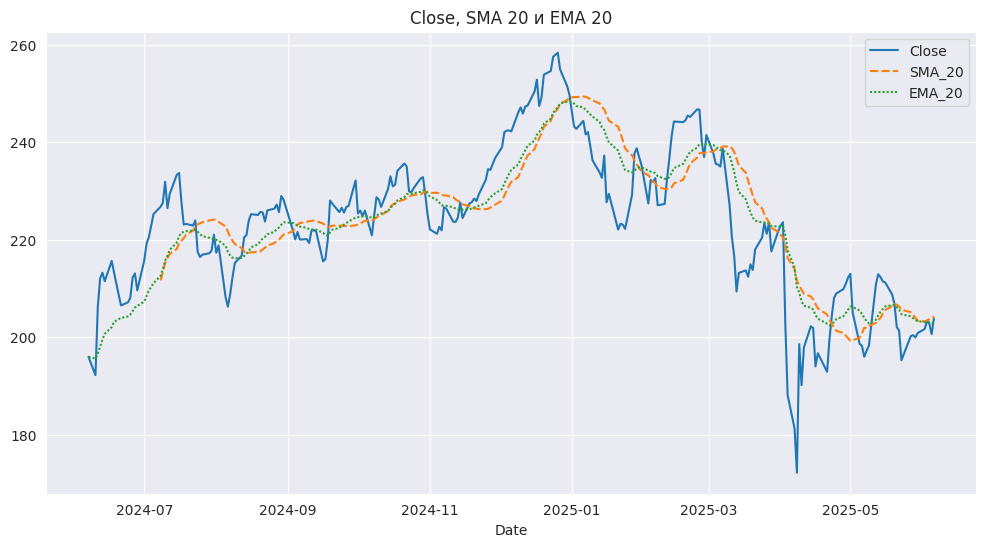

In [36]:
plt.figure(figsize=(12,6))
sns.lineplot(data=data[['Close','SMA_20','EMA_20']])
plt.title("Close, SMA 20 и EMA 20")
plt.show()

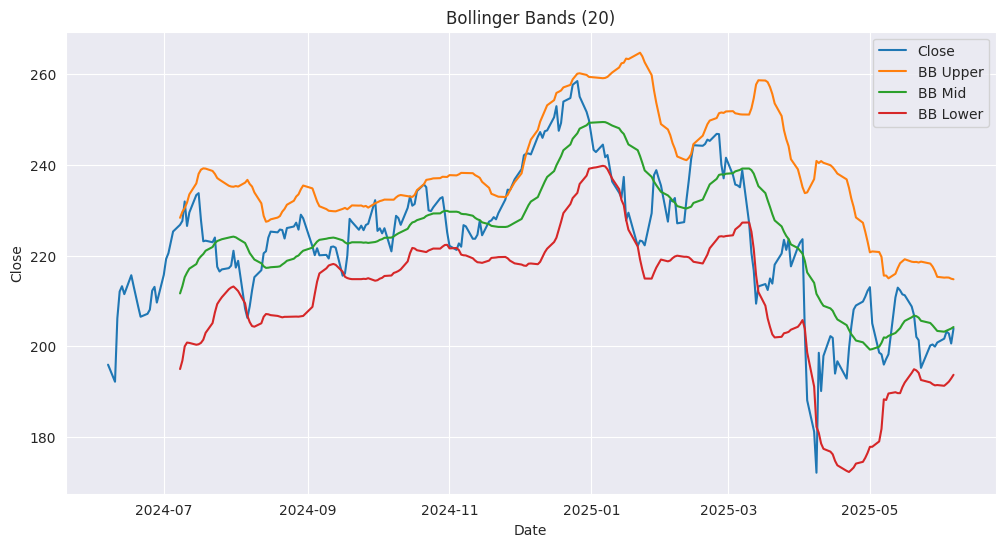

In [37]:
plt.figure(figsize=(12,6))
sns.lineplot(data=data['Close'], label='Close')
sns.lineplot(data=data['BB_upper'], label='BB Upper')
sns.lineplot(data=data['BB_mid'], label='BB Mid')
sns.lineplot(data=data['BB_lower'], label='BB Lower')
plt.title("Bollinger Bands (20)")
plt.show()

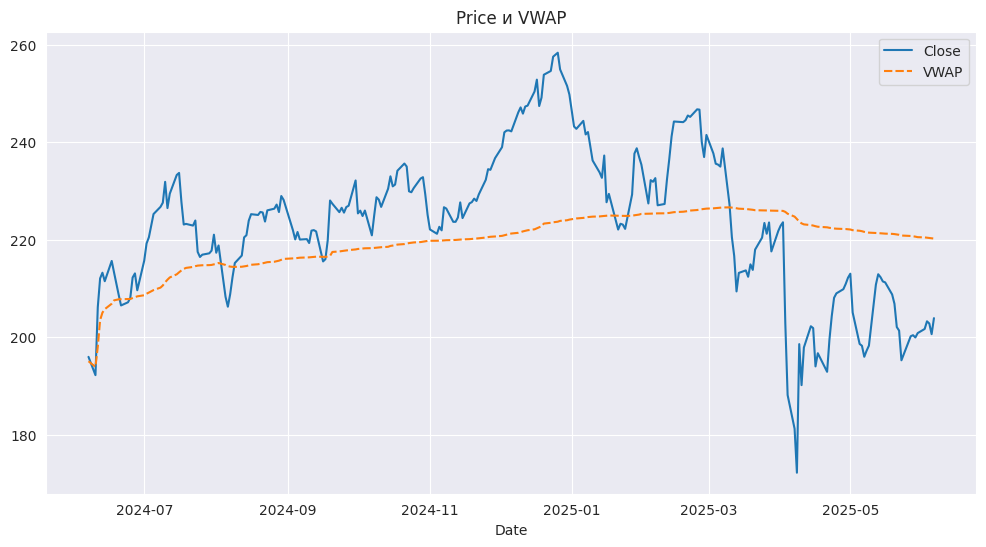

In [38]:
plt.figure(figsize=(12,6))
sns.lineplot(data=data[['Close','VWAP']])
plt.title("Price и VWAP")
plt.show()

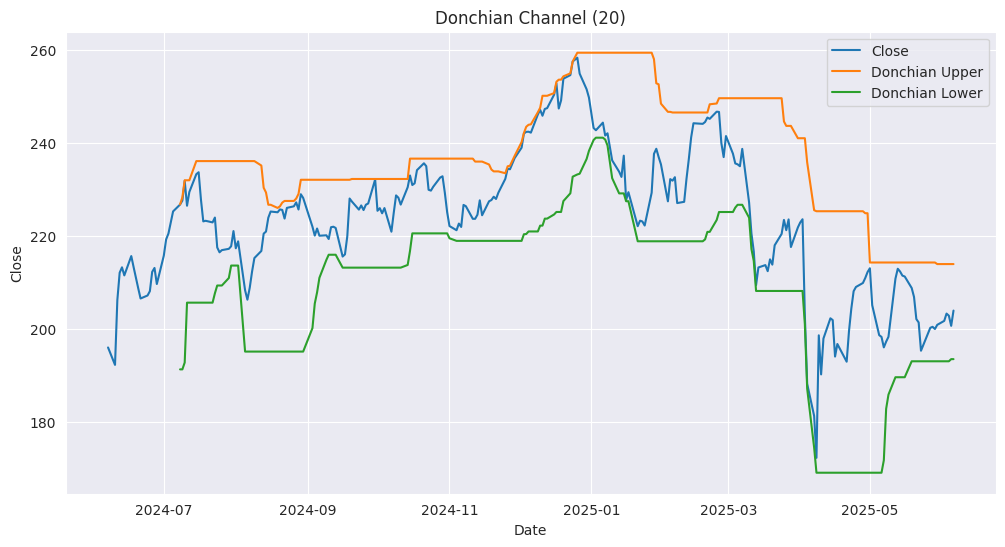

In [39]:
plt.figure(figsize=(12,6))
sns.lineplot(data=data['Close'], label='Close')
sns.lineplot(data=data['DC_upper_20'], label='Donchian Upper')
sns.lineplot(data=data['DC_lower_20'], label='Donchian Lower')
plt.title("Donchian Channel (20)")
plt.show()

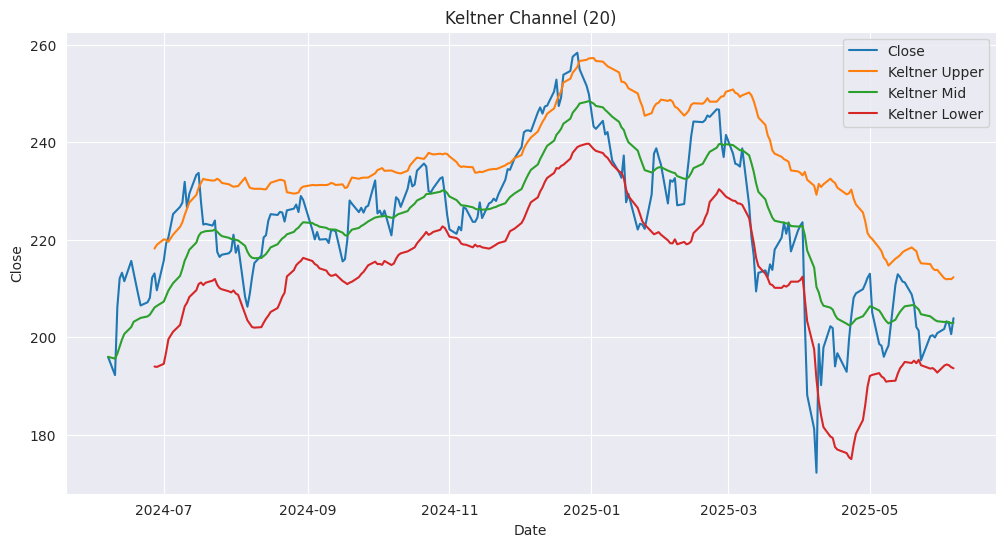

In [40]:
plt.figure(figsize=(12,6))
sns.lineplot(data=data['Close'], label='Close')
sns.lineplot(data=data['KC_upper_20'], label='Keltner Upper')
sns.lineplot(data=data['KC_mid_20'],  label='Keltner Mid')
sns.lineplot(data=data['KC_lower_20'], label='Keltner Lower')
plt.title("Keltner Channel (20)")
plt.show()

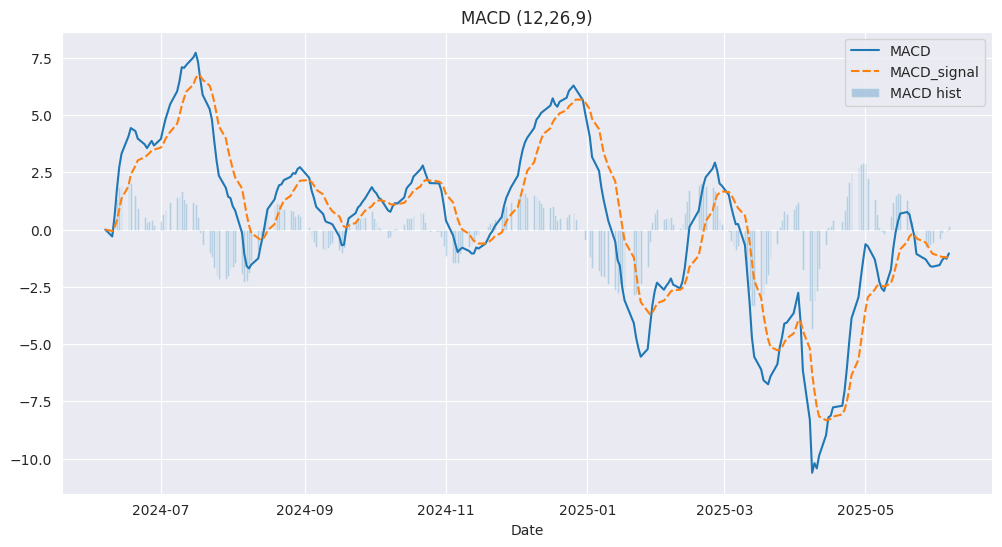

In [41]:
plt.figure(figsize=(12,6))
sns.lineplot(data=data[['MACD','MACD_signal']])
plt.bar(data.index, data['MACD_hist'], alpha=0.3, label='MACD hist')
plt.title("MACD (12,26,9)")
plt.legend()
plt.show()

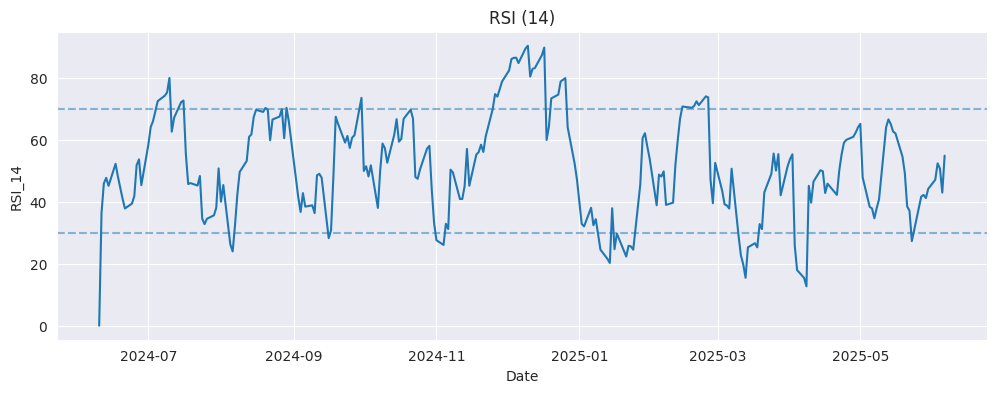

In [42]:
plt.figure(figsize=(12,4))
sns.lineplot(data=data['RSI_14'])
plt.axhline(70, linestyle='--', alpha=0.5)
plt.axhline(30, linestyle='--', alpha=0.5)
plt.title("RSI (14)")
plt.show()

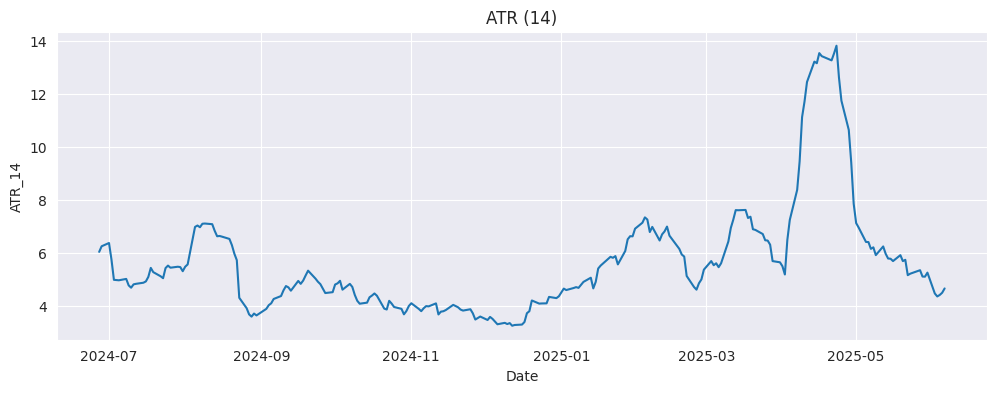

In [43]:
plt.figure(figsize=(12,4))
sns.lineplot(data=data['ATR_14'])
plt.title("ATR (14)")
plt.show()

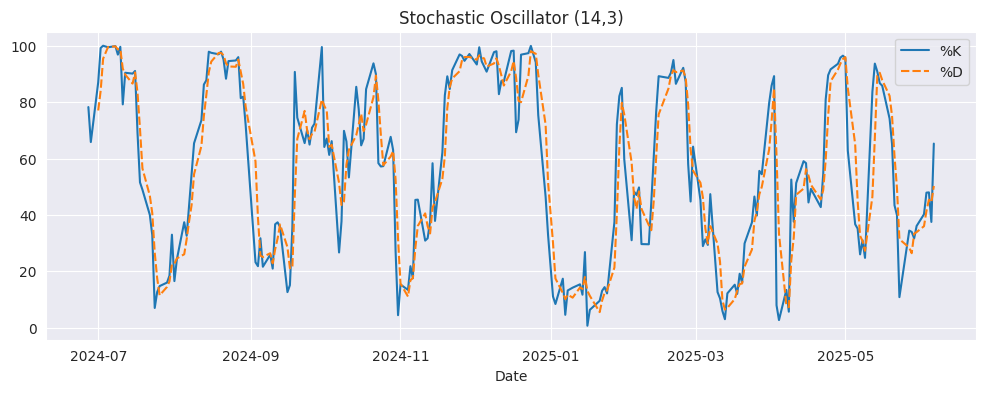

In [44]:
plt.figure(figsize=(12,4))
sns.lineplot(data=data[['%K','%D']])
plt.title("Stochastic Oscillator (14,3)")
plt.show()

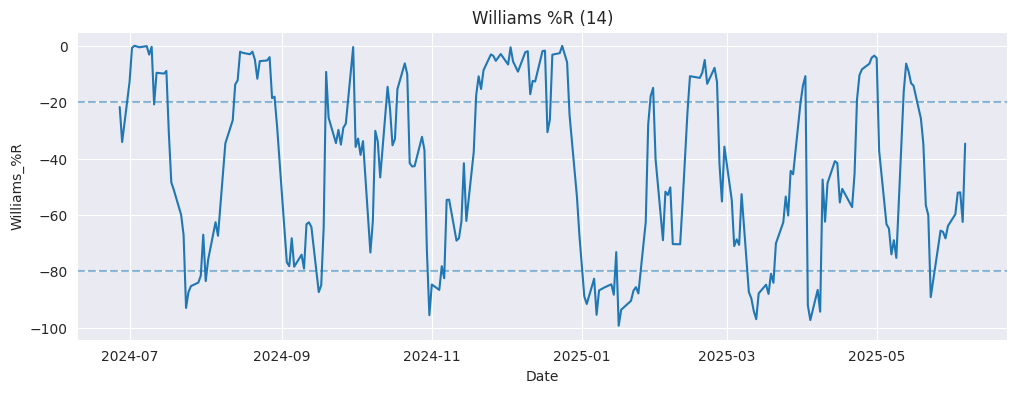

In [45]:
plt.figure(figsize=(12,4))
sns.lineplot(data=data['Williams_%R'])
plt.axhline(-20, linestyle='--', alpha=0.5)
plt.axhline(-80, linestyle='--', alpha=0.5)
plt.title("Williams %R (14)")
plt.show()

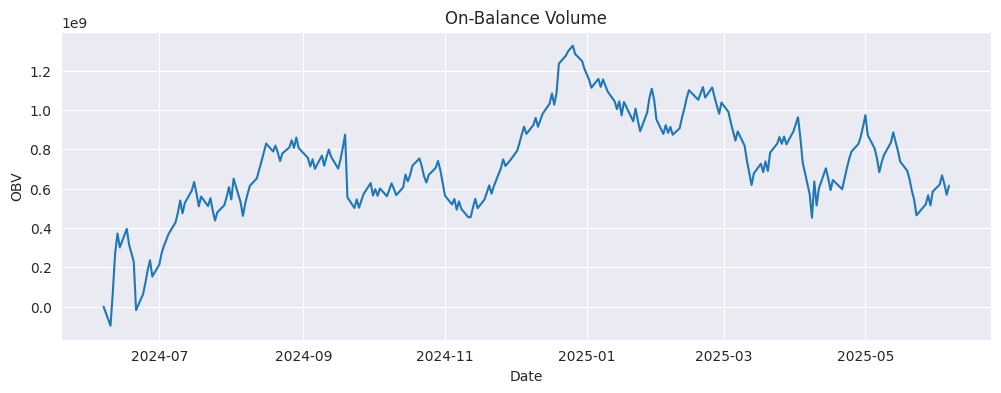

In [46]:
plt.figure(figsize=(12,4))
sns.lineplot(data=data['OBV'])
plt.title("On-Balance Volume")
plt.show()

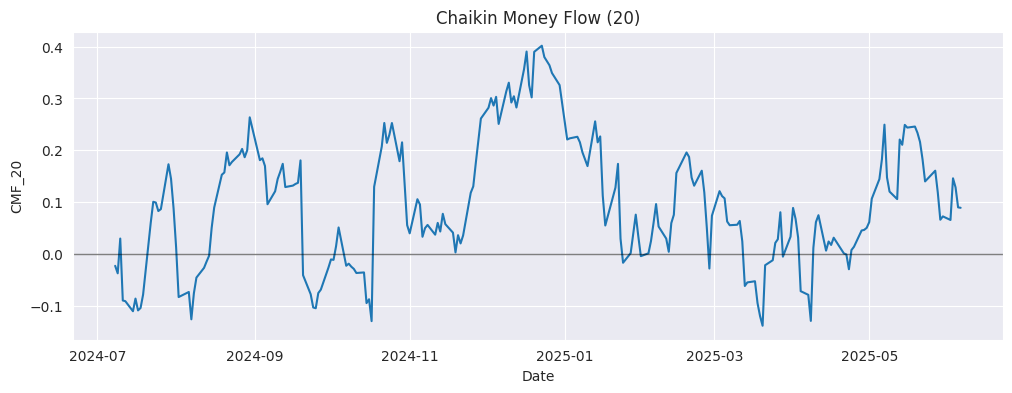

In [47]:
plt.figure(figsize=(12,4))
sns.lineplot(data=data['CMF_20'])
plt.axhline(0, color='black', linewidth=1, alpha=0.5)
plt.title("Chaikin Money Flow (20)")
plt.show()

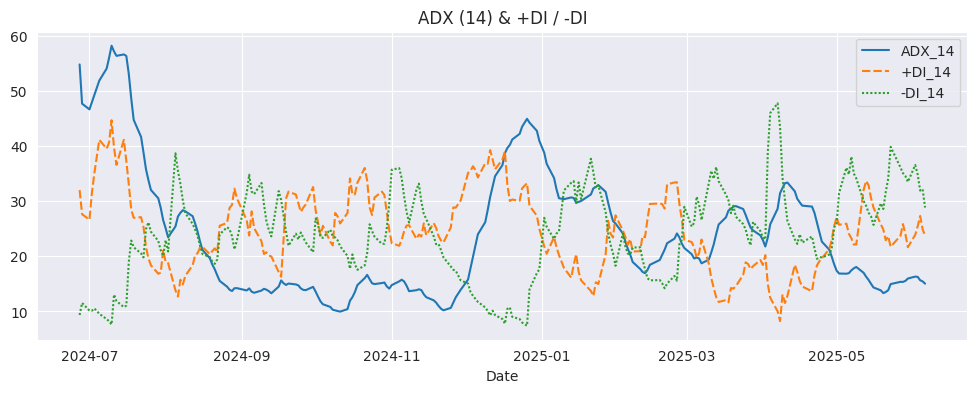

In [49]:
plt.figure(figsize=(12,4))
sns.lineplot(data=data[['ADX_14','+DI_14','-DI_14']])
plt.title("ADX (14) & +DI / -DI")
plt.show()

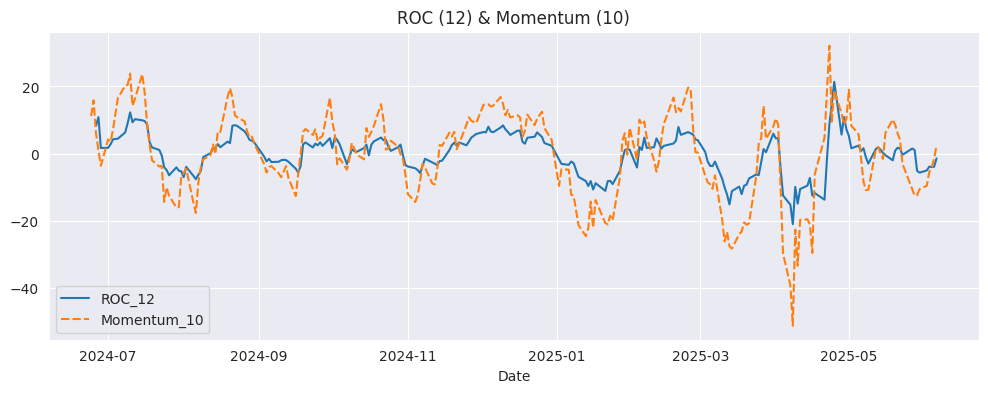

In [51]:
plt.figure(figsize=(12,4))
sns.lineplot(data=data[['ROC_12','Momentum_10']])
plt.title("ROC (12) & Momentum (10)")
plt.show()

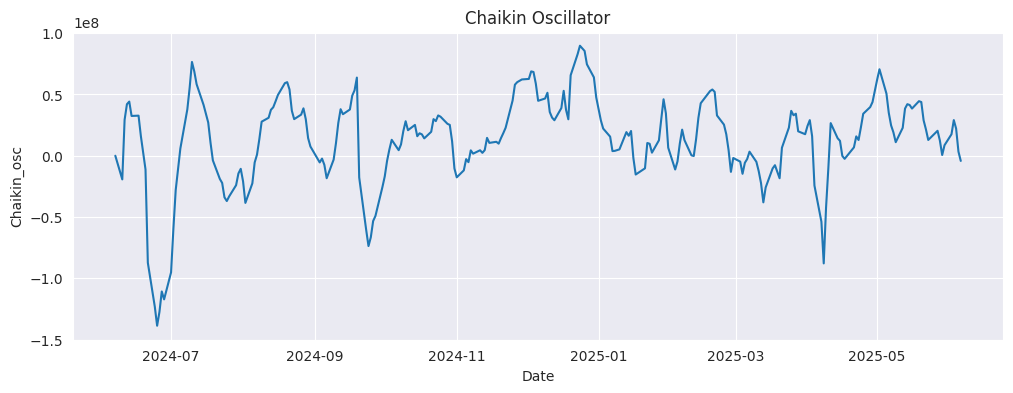

In [53]:
plt.figure(figsize=(12,4))
sns.lineplot(data=data['Chaikin_osc'])
plt.title("Chaikin Oscillator")
plt.show()

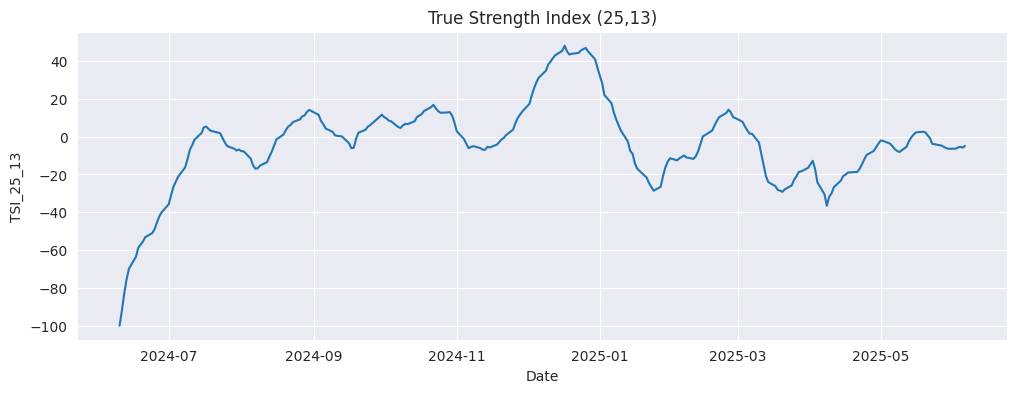

In [54]:
plt.figure(figsize=(12,4))
sns.lineplot(data=data['TSI_25_13'])
plt.title("True Strength Index (25,13)")
plt.show()

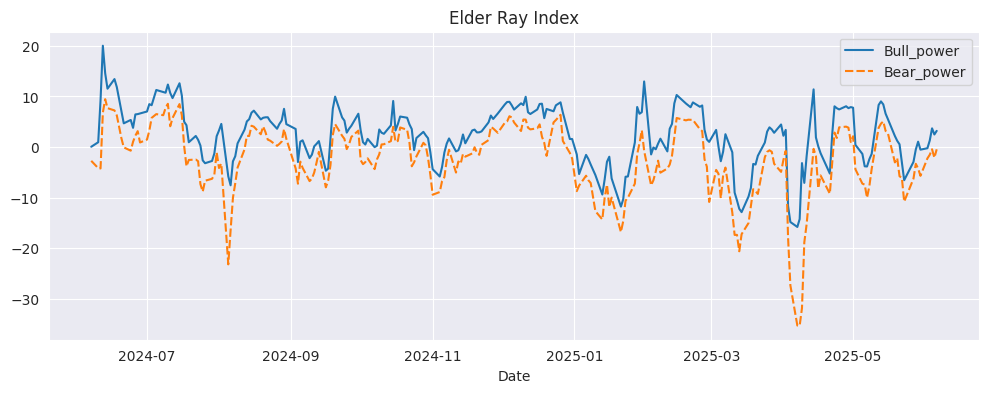

In [55]:
plt.figure(figsize=(12,4))
sns.lineplot(data=data[['Bull_power','Bear_power']])
plt.title("Elder Ray Index")
plt.show()

### Автоматический расчет индикаторов с помощью TA.

https://technical-analysis-library-in-python.readthedocs.io/en/latest/

In [59]:
#!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=6902b448b8d08b7a5215d2160fe833be088afa0ae00441205d249f5a3d588629
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [60]:
import ta

In [62]:
# Снова формирование датасета

def fetch_data():
    ticker = input("Enter ticker (e.g. 'AAPL'): ").strip().upper()
    period = input("Enter period (e.g. '1mo', '1y', 'max'): ").strip()
    interval = input("Enter interval (e.g. '1d', '1h', '5m'): ").strip()

    data = yf.Ticker(ticker).history(period=period, interval=interval)
    return data

if __name__ == "__main__":
    data = fetch_data()
    print(data)

Enter ticker (e.g. 'AAPL'): AAPL
Enter period (e.g. '1mo', '1y', 'max'): 1y
Enter interval (e.g. '1d', '1h', '5m'): 1d
                                 Open        High         Low       Close  \
Date                                                                        
2024-06-10 00:00:00-04:00  195.983442  196.381589  191.255553  192.221039   
2024-06-11 00:00:00-04:00  192.748557  206.195678  192.728661  206.185715   
2024-06-12 00:00:00-04:00  206.404707  219.174986  205.936893  212.078186   
2024-06-13 00:00:00-04:00  213.740409  215.741048  210.615026  213.242737   
2024-06-14 00:00:00-04:00  212.854555  214.168403  210.316422  211.500885   
...                               ...         ...         ...         ...   
2025-06-03 00:00:00-04:00  201.350006  203.770004  200.960007  203.270004   
2025-06-04 00:00:00-04:00  202.910004  206.240005  202.100006  202.820007   
2025-06-05 00:00:00-04:00  203.500000  204.750000  200.149994  200.630005   
2025-06-06 00:00:00-04:00  203.000

In [63]:
data_ta = data.copy()
data_ta = ta.add_all_ta_features(
    df=data_ta,
    open="Open", high="High", low="Low", close="Close", volume="Volume",
    fillna=True
)

/usr/local/lib/python3.11/dist-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


In [65]:
data_ta.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,volume_adi,volume_obv,volume_cmf,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02,250.000000,250.0,2.500000e+02,2.500000e+02,250.000000,...,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,222.810510,225.487224,220.466014,223.192531,5.599669e+07,0.004040,0.0,3.357602e+08,9.414420e+08,0.080723,...,0.143797,0.152351,-0.008554,-2.392258,-2.285097,-0.107161,222.322359,0.047681,0.026233,16.112436
std,15.224997,14.470064,15.513107,15.023596,3.257590e+07,0.031751,0.0,3.642581e+08,2.580155e+08,0.138685,...,1.719997,1.570939,0.621814,9.227389,7.193375,5.151178,14.947620,2.087119,2.069940,7.815792
min,171.724805,190.090729,168.988411,172.194199,5.888322e+06,0.000000,0.0,-3.461210e+08,9.726210e+07,-0.623301,...,-4.964751,-3.911188,-2.095176,-17.855923,-16.470245,-10.397196,192.221039,-9.245608,-9.701332,-10.418652
25%,212.874454,215.233423,210.588758,213.130150,3.953412e+07,0.000000,0.0,1.036263e+07,7.721619e+08,-0.004324,...,-0.714587,-0.594329,-0.356832,-7.941428,-6.603977,-2.748173,212.661509,-0.731053,-0.733739,10.877639
50%,224.170641,226.070012,222.231364,224.210571,4.726930e+07,0.000000,0.0,3.343160e+08,9.335952e+08,0.072932,...,0.285296,0.303356,0.109054,-3.005429,-2.389841,-0.379372,225.128879,0.171397,0.171250,16.642056
75%,232.447929,234.263584,229.182156,232.515671,6.036088e+07,0.000000,0.0,6.614012e+08,1.120218e+09,0.175057,...,1.073856,0.942261,0.384090,1.861683,2.438014,1.997328,229.738742,1.027003,1.021765,20.962654
max,257.568678,259.474086,257.010028,258.396667,3.186799e+08,0.260000,0.0,9.762256e+08,1.560975e+09,0.413502,...,3.779162,3.428457,1.398668,32.461832,18.616854,27.606522,252.157925,15.328847,14.261740,34.426840


volume_adi — индекс накопления/распределения (Accumulation/Distribution Index)

volume_obv — On-Balance Volume (накапливаемый объём)

volume_cmf — Chaikin Money Flow (денежный поток Чайкина)

volume_fi — Force Index (индекс силы)

volume_em — Ease of Movement (индекс легкости движения)

volume_sma_em — скользящая средняя Ease of Movement

volume_vpt — Volume Price Trend (тренд по объёму/цене)

volume_vwap — Volume Weighted Average Price (средневзвешенная цена объёма)

volume_mfi — Money Flow Index (индекс денежного потока)

volume_nvi — Negative Volume Index (индекс отрицательного объёма)

volatility_bbm — средняя полоса Боллинджера (Bollinger Middle Band)

volatility_bbh — верхняя полоса Боллинджера (Bollinger High Band)

volatility_bbl — нижняя полоса Боллинджера (Bollinger Low Band)

volatility_bbw — ширина полос Боллинджера (Bollinger Band Width)

volatility_bbp — %B полос Боллинджера (Bollinger %B)

volatility_bbhi — индикатор прорыва верхней полосы Боллинджера

volatility_bbli — индикатор прорыва нижней полосы Боллинджера

volatility_kcc — средняя полоса Кельтнера (Keltner Channel Middle)

volatility_kch — верхняя полоса Кельтнера (Keltner Channel High)

volatility_kcl — нижняя полоса Кельтнера (Keltner Channel Low)

volatility_kcw — ширина каналов Кельтнера (Keltner Channel Width)

volatility_kcp — %K каналов Кельтнера (Keltner Channel %p)

volatility_kchi — индикатор прорыва верхней линии Кельтнера

volatility_kcli — индикатор прорыва нижней линии Кельтнера

volatility_dcl — нижняя полоса Дончана (Donchian Channel Lower)

volatility_dch — верхняя полоса Дончана (Donchian Channel Upper)

volatility_dcm — средняя полоса Дончана (Donchian Channel Middle)

volatility_dcw — ширина канала Дончана (Donchian Channel Width)

volatility_dcp — %D полос Дончана (Donchian Channel %p)

volatility_atr — Average True Range (средний истинный диапазон)

volatility_ui — Ulcer Index (индекс язвы)

trend_macd — MACD линия (Moving Average Convergence Divergence)

trend_macd_signal — сигнальная линия MACD

trend_macd_diff — гистограмма MACD (разница MACD и сигнала)

trend_sma_fast — быстрая скользящая средняя (SMA fast)

trend_sma_slow — медленная скользящая средняя (SMA slow)

trend_ema_fast — быстрая экспоненциальная MA (EMA fast)

trend_ema_slow — медленная экспоненциальная MA (EMA slow)

trend_vortex_ind_pos — положительный Vortex Indicator

trend_vortex_ind_neg — отрицательный Vortex Indicator

trend_vortex_ind_diff — разница Vortex Indicator

trend_trix — TRIX (Triple Exponential Average)

trend_mass_index — Mass Index (индекс массы)

trend_dpo — Detrended Price Oscillator

trend_kst — KST (Know Sure Thing)

trend_kst_sig — сигнальная линия KST

trend_kst_diff — разница KST и сигнала

trend_ichimoku_conv — линия конверсии Ишимоку (Tenkan-sen)

trend_ichimoku_base — базовая линия Ишимоку (Kijun-sen)

trend_ichimoku_a — Senkou Span A (линия А)

trend_ichimoku_b — Senkou Span B (линия B)

trend_stc — Schaff Trend Cycle

trend_adx — ADX (Average Directional Index)

trend_adx_pos — +DI (положительный Directional Indicator)

trend_adx_neg — -DI (отрицательный Directional Indicator)

trend_cci — CCI (Commodity Channel Index)

trend_visual_ichimoku_a — визуальная линия Ишимоку A

trend_visual_ichimoku_b — визуальная линия Ишимоку B

trend_aroon_up — Aroon Up

trend_aroon_down — Aroon Down

trend_aroon_ind — Aroon Oscillator (разница Up–Down)

trend_psar_up — Parabolic SAR (значение для восходящего тренда)

trend_psar_down — Parabolic SAR (значение для нисходящего тренда)

trend_psar_up_indicator — индикатор сигнала PSAR (вверх)

trend_psar_down_indicator — индикатор сигнала PSAR (вниз)

momentum_rsi — RSI (Relative Strength Index)

momentum_stoch_rsi — Stochastic RSI

momentum_stoch_rsi_k — %K для Stochastic RSI

momentum_stoch_rsi_d — %D для Stochastic RSI

momentum_tsi — True Strength Index

momentum_uo — Ultimate Oscillator

momentum_stoch — Stochastic Oscillator

momentum_stoch_signal — сигнальная линия Stochastic Oscillator

momentum_wr — Williams %R

momentum_ao — Awesome Oscillator

momentum_roc — Rate of Change (ROC)

momentum_ppo — Percentage Price Oscillator (PPO)

momentum_ppo_signal — сигнальная линия PPO

momentum_ppo_hist — гистограмма PPO

momentum_pvo — Percentage Volume Oscillator (PVO)

momentum_pvo_signal — сигнальная линия PVO

momentum_pvo_hist — гистограмма PVO

momentum_kama — Kaufman Adaptive Moving Average (KAMA)

others_dr — ежедневная доходность (daily return)

others_dlr — ежедневная логарифмическая доходность

others_cr — кумулятивная доходность (cumulative return)

In [66]:
orig = set(data.columns)
all_cols = list(data_ta.columns)
new_inds = [c for c in all_cols if c not in orig]

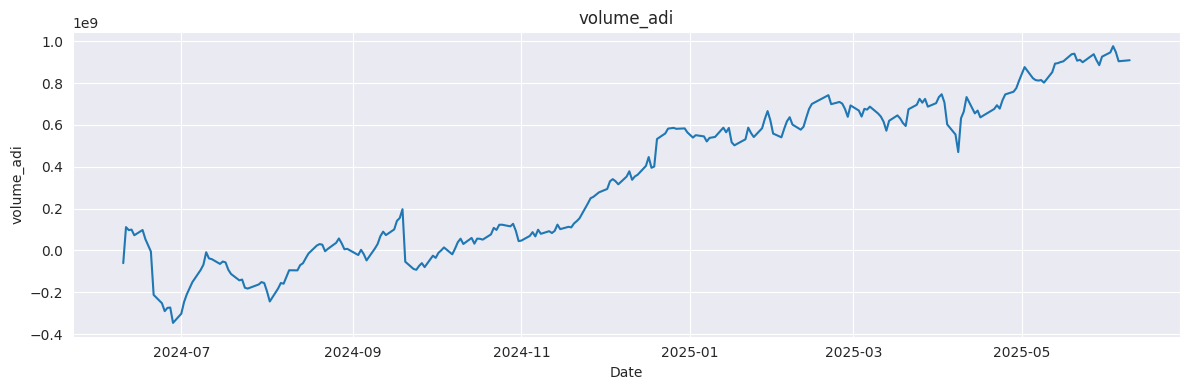

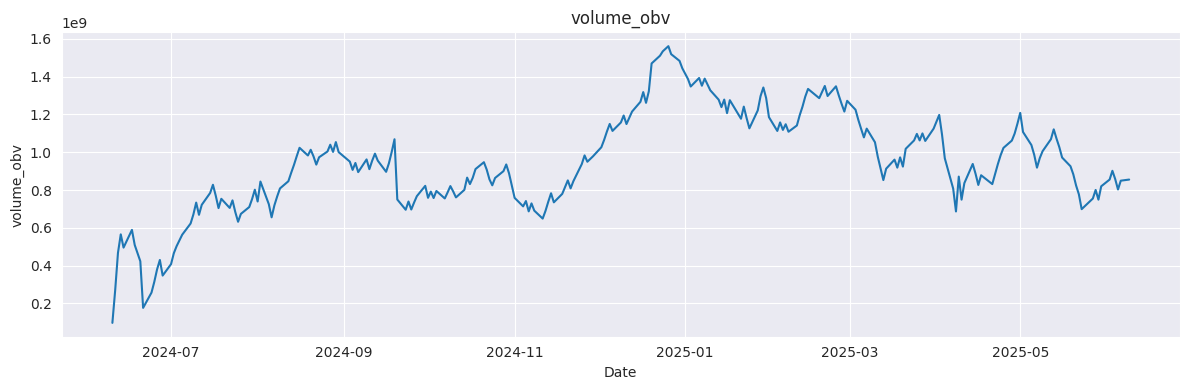

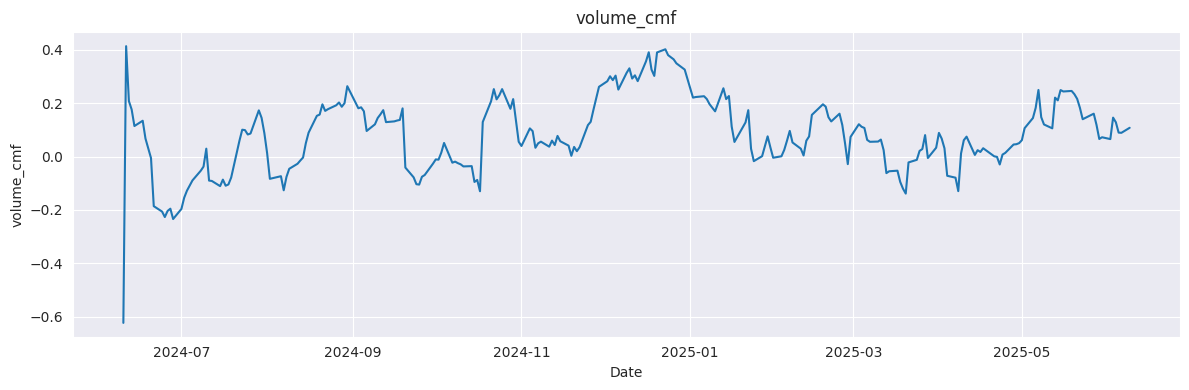

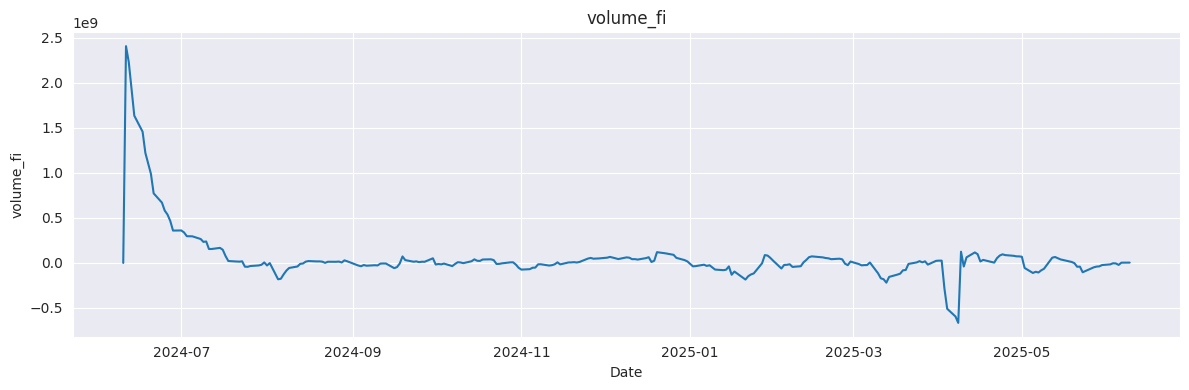

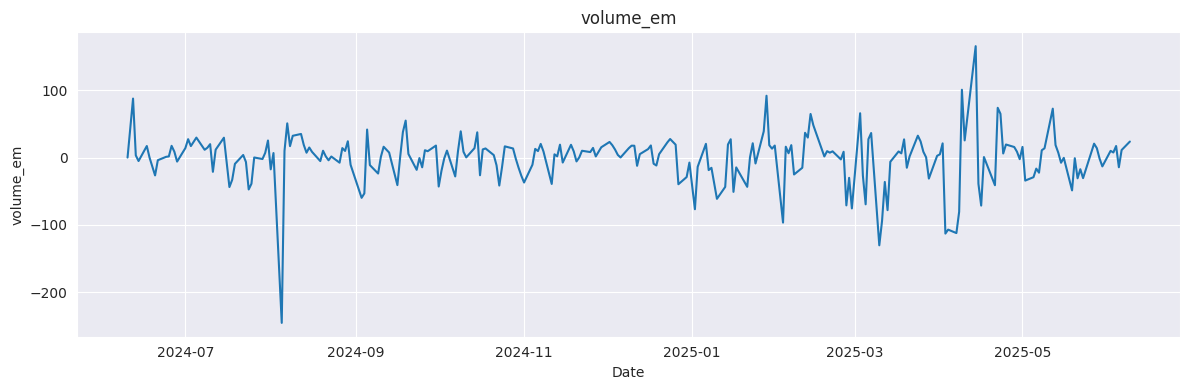

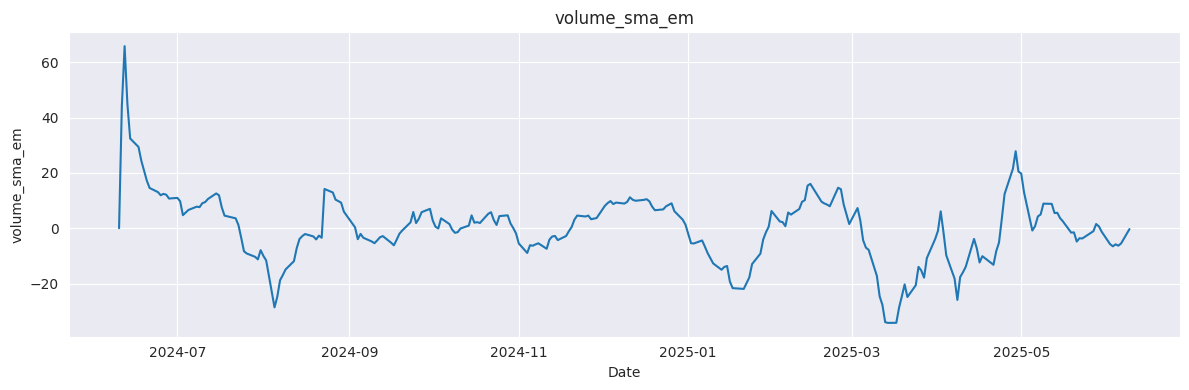

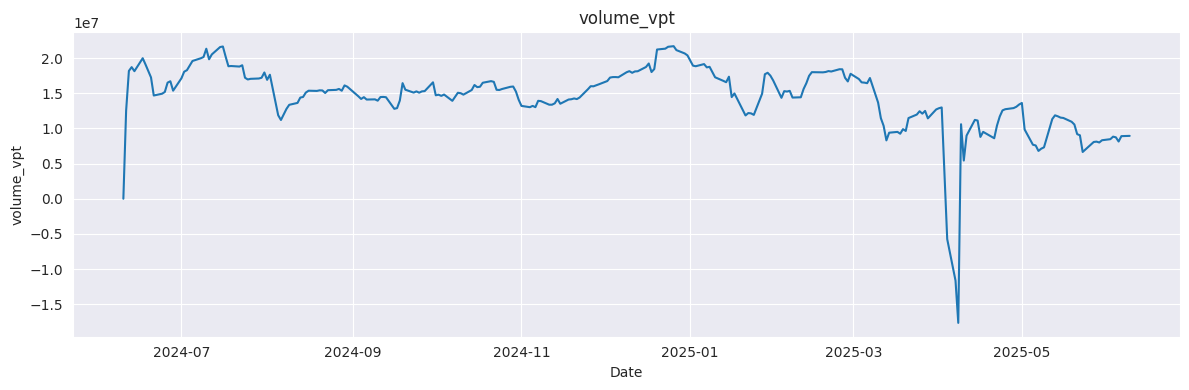

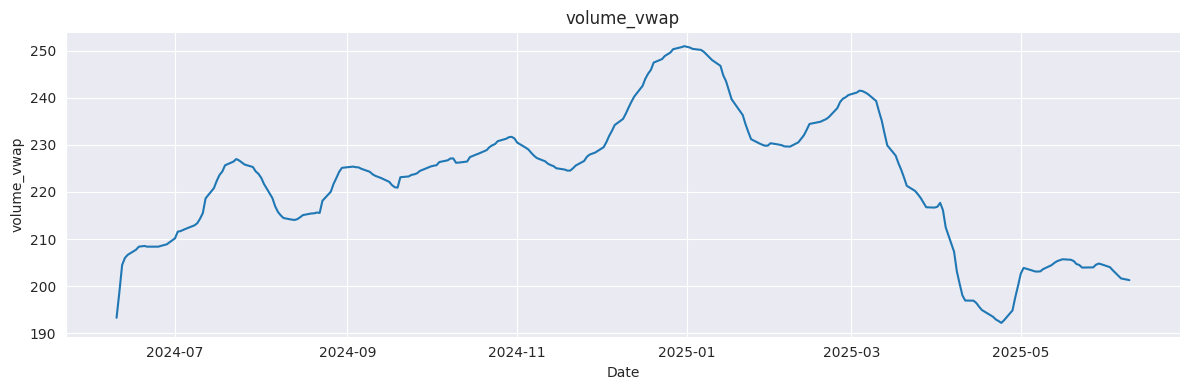

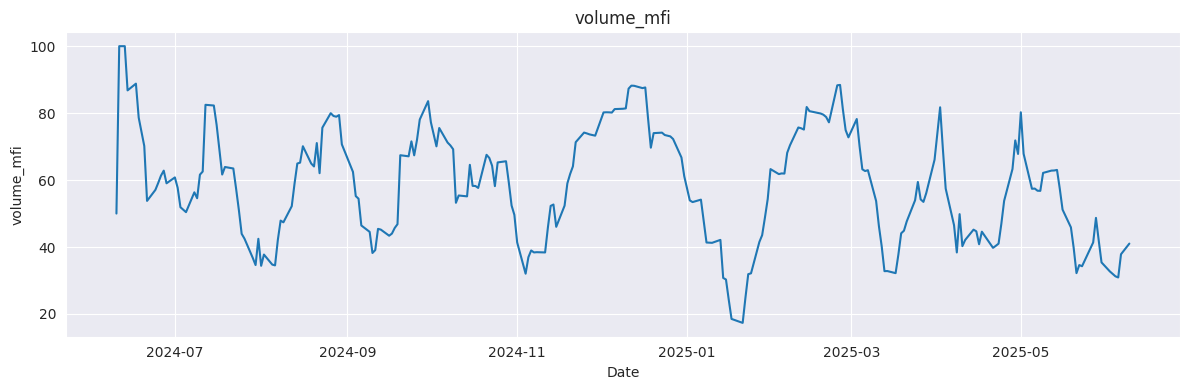

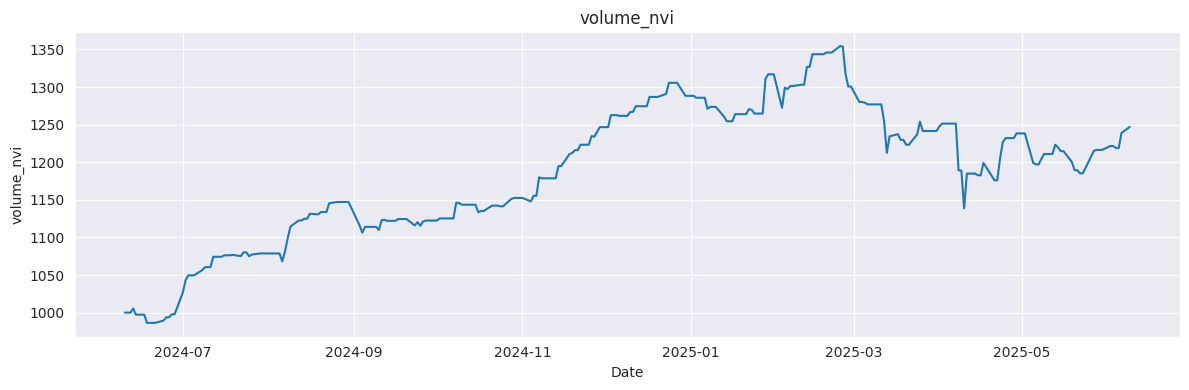

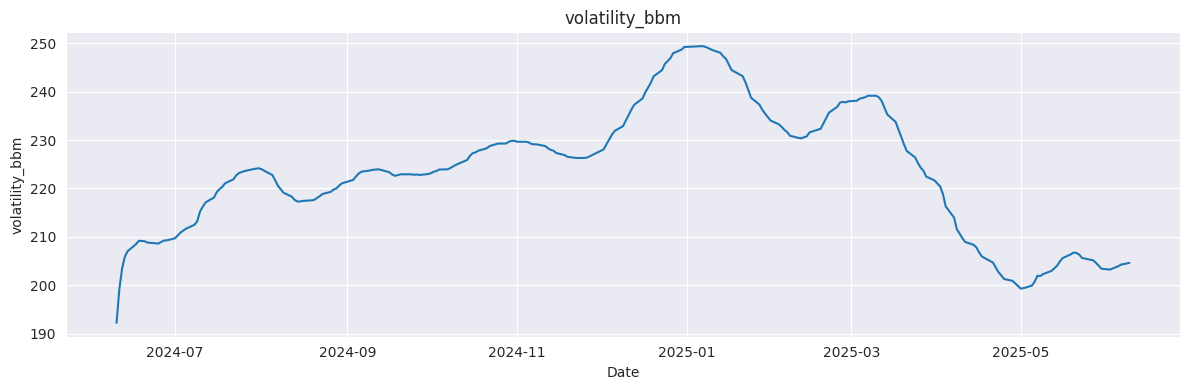

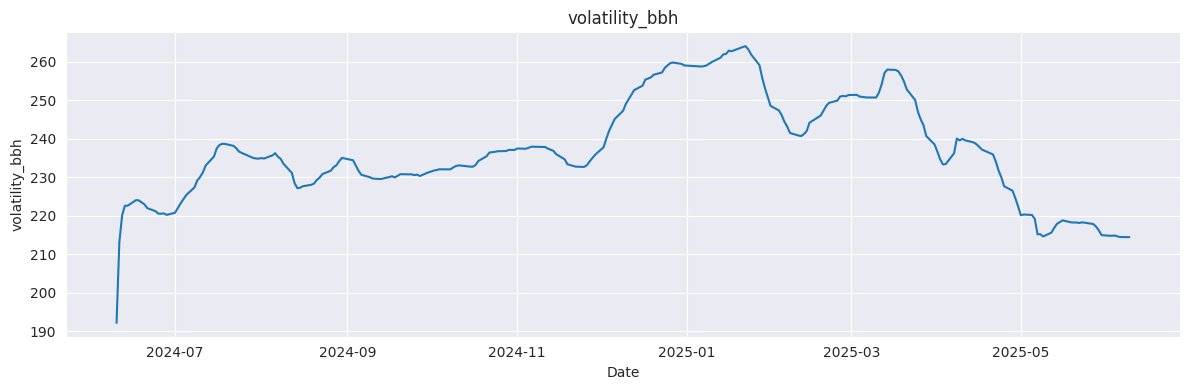

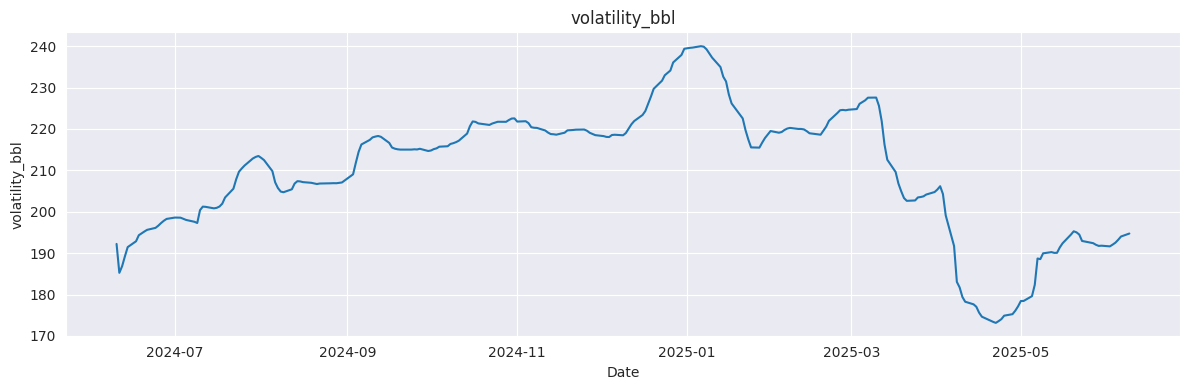

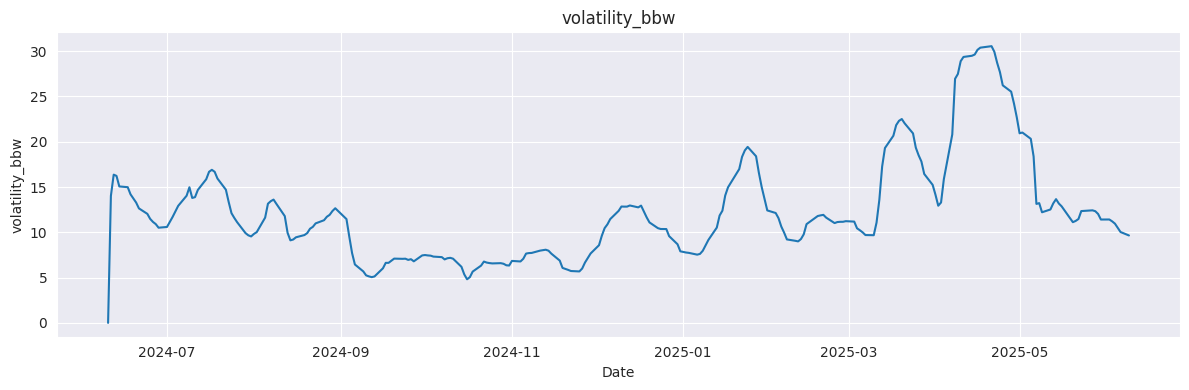

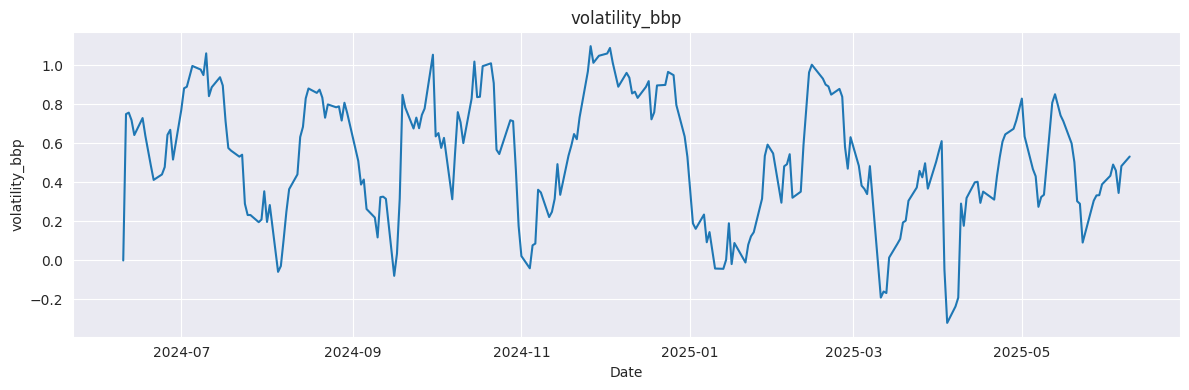

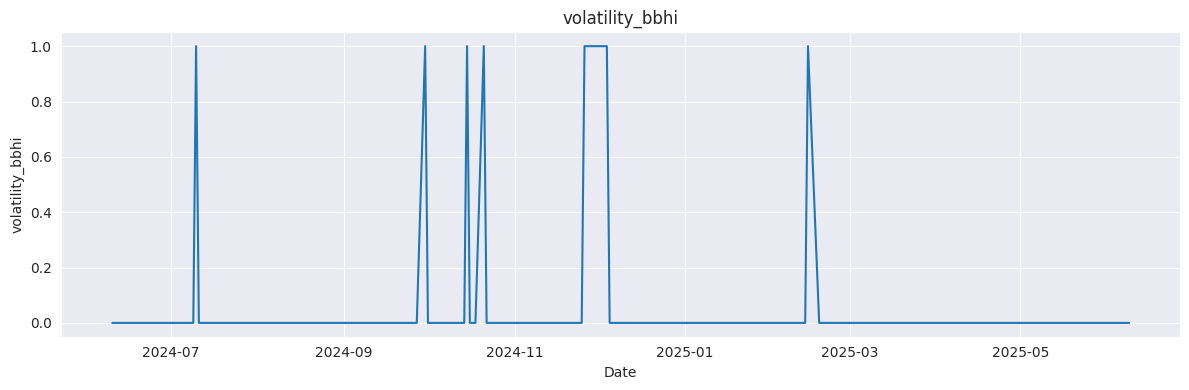

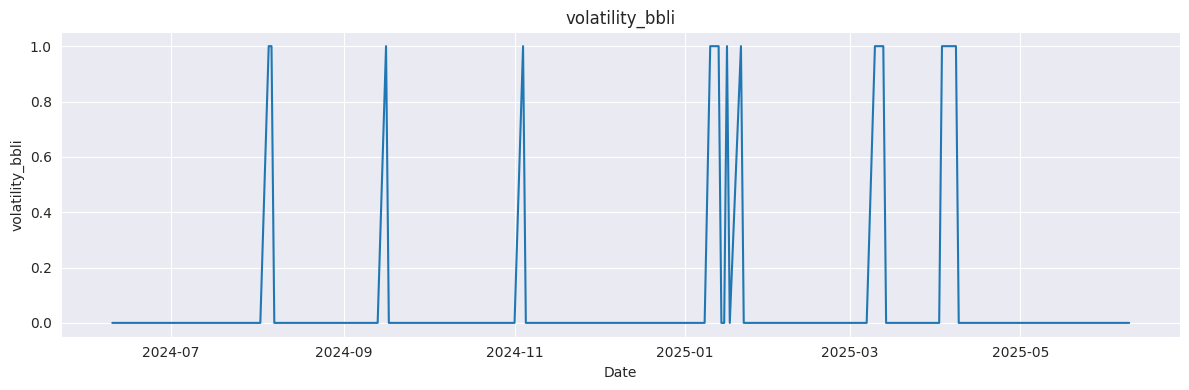

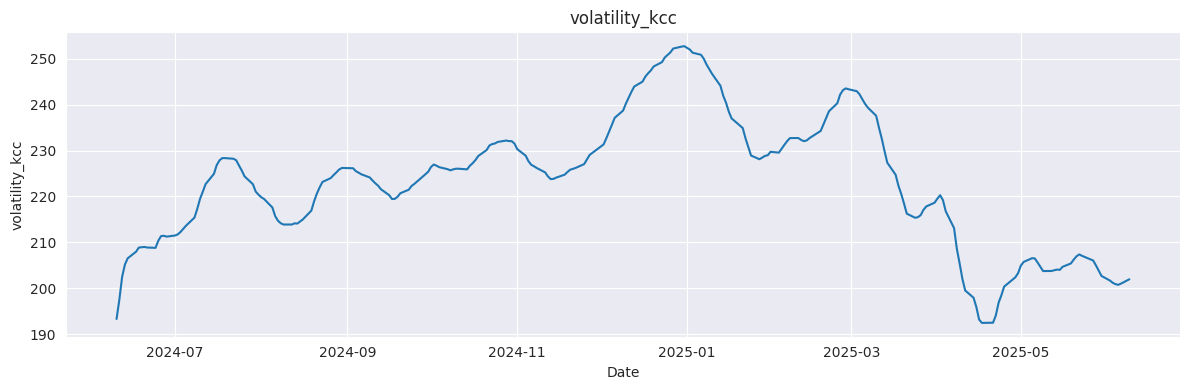

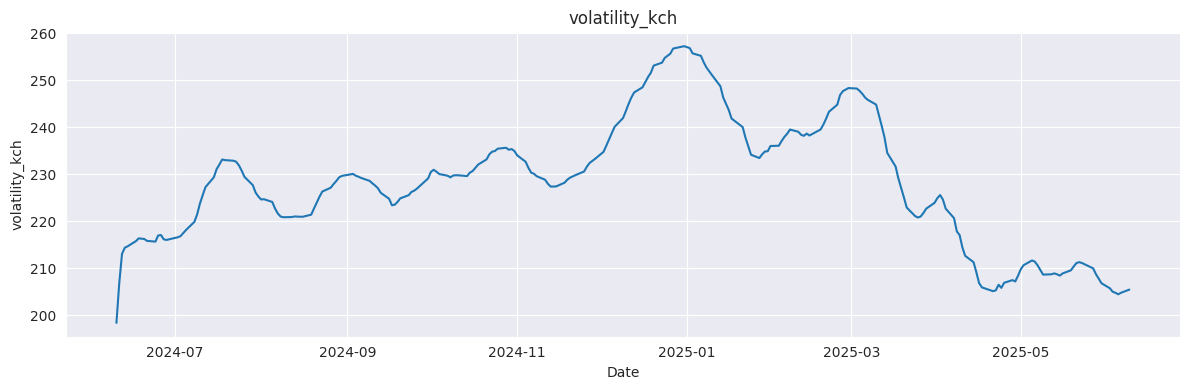

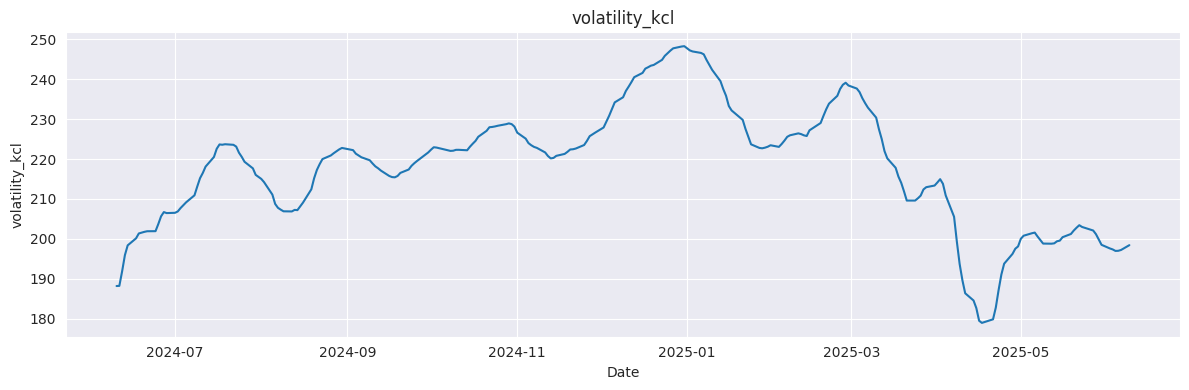

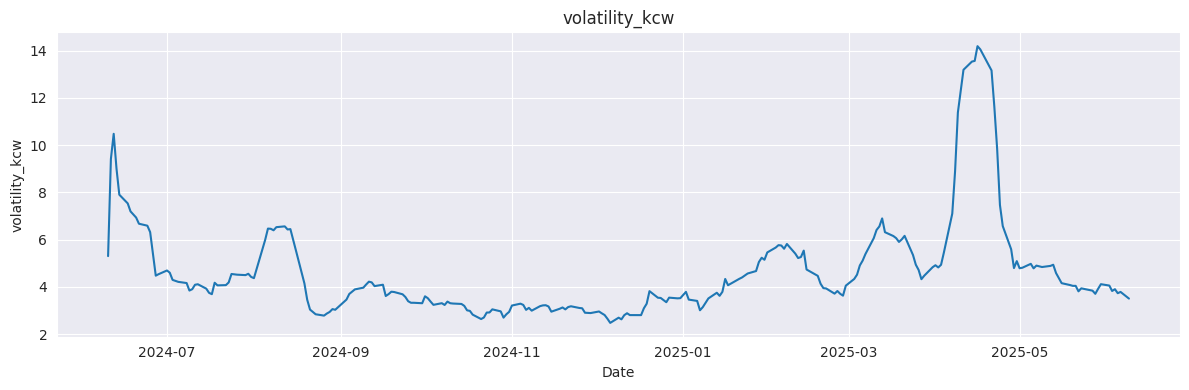

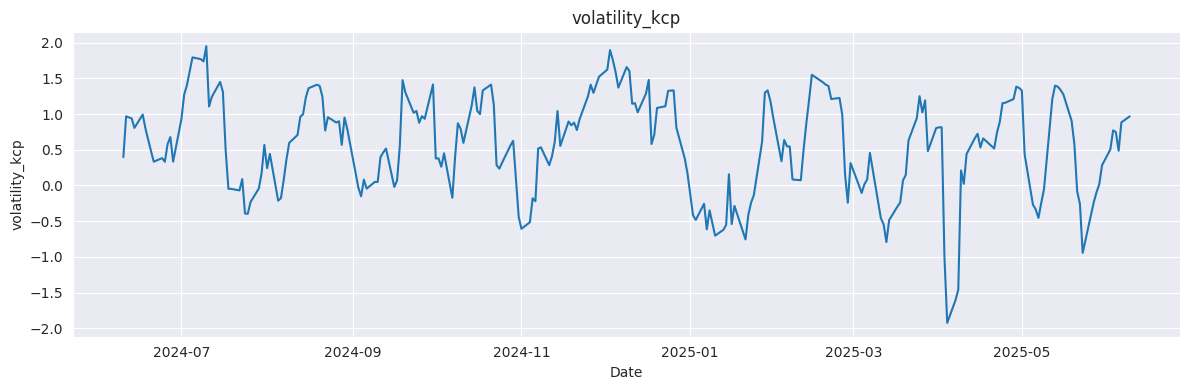

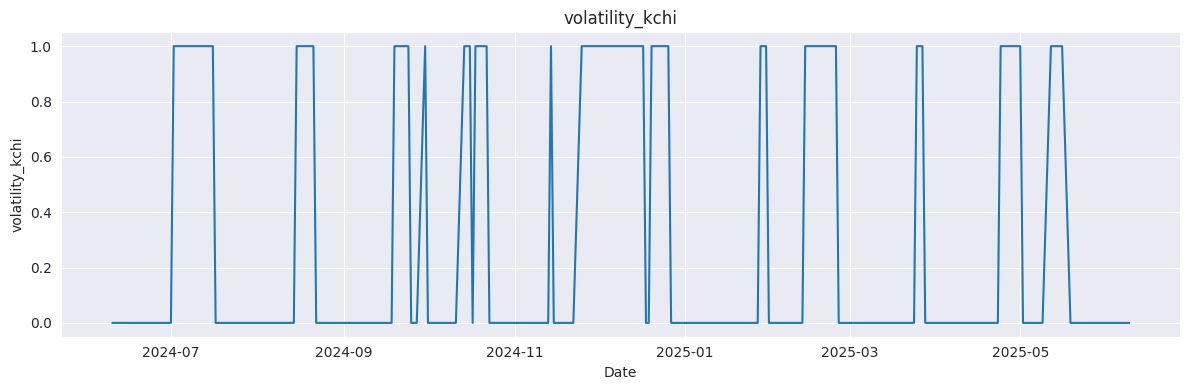

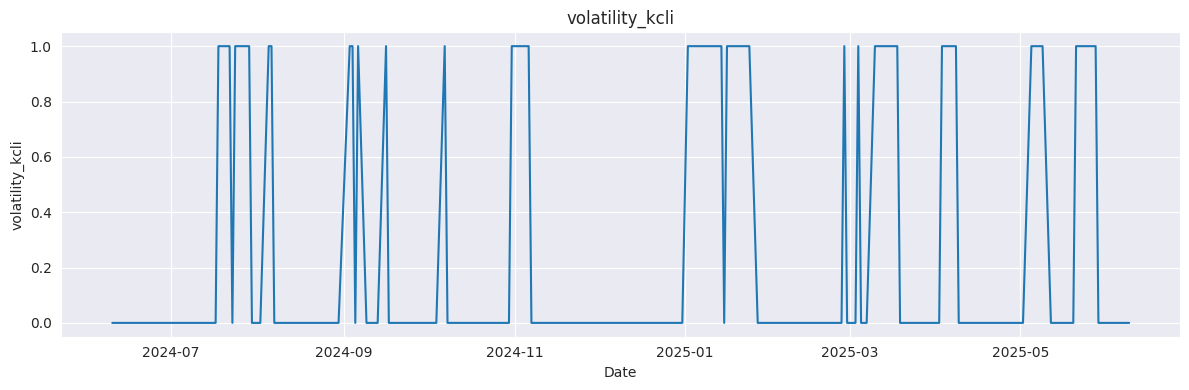

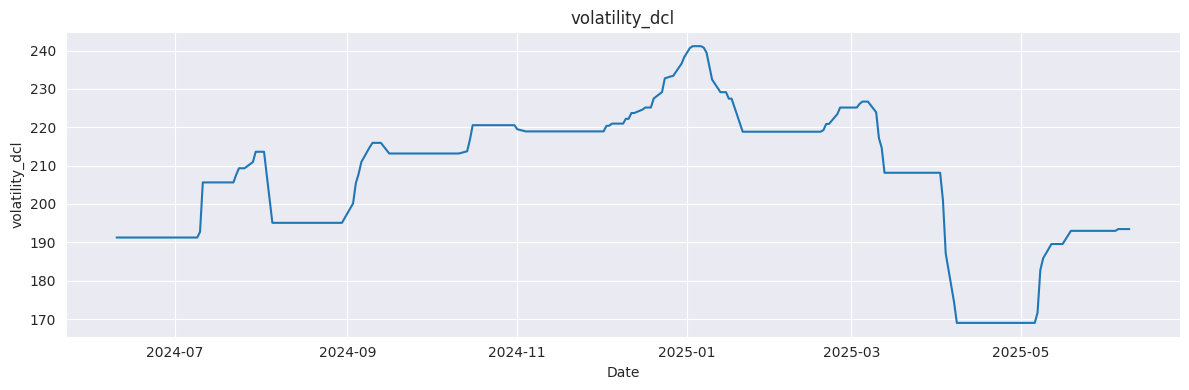

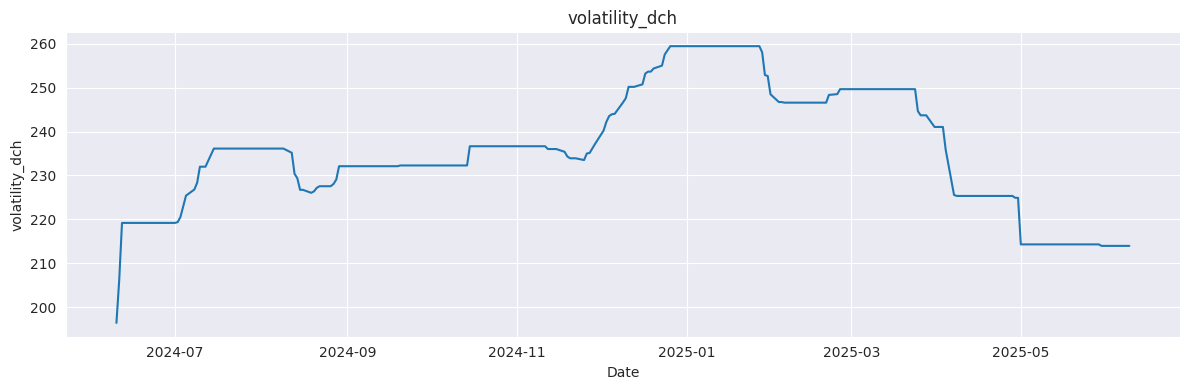

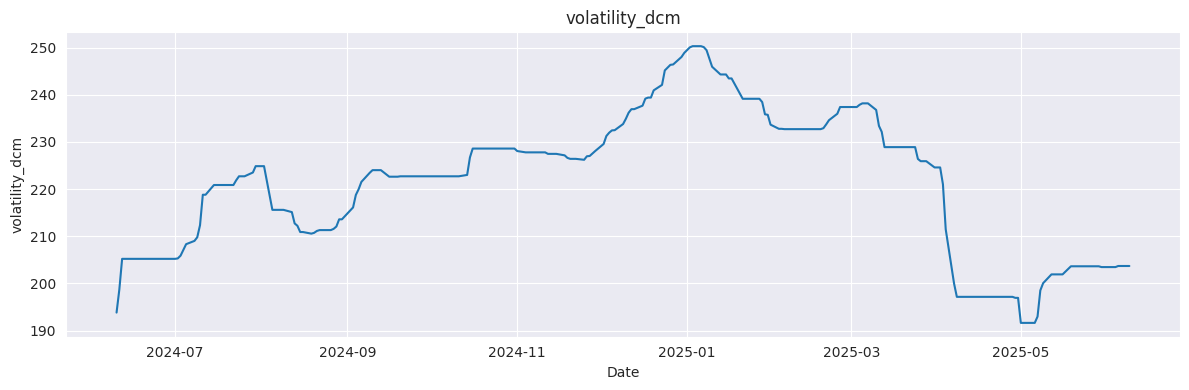

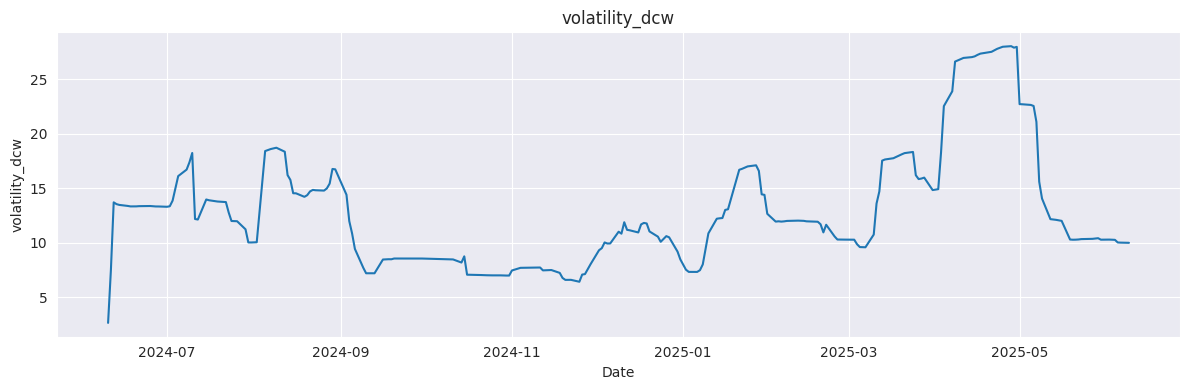

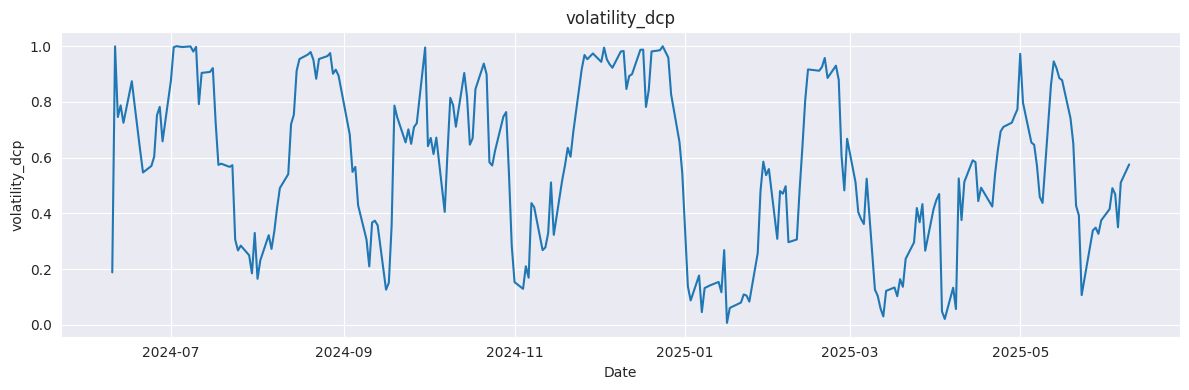

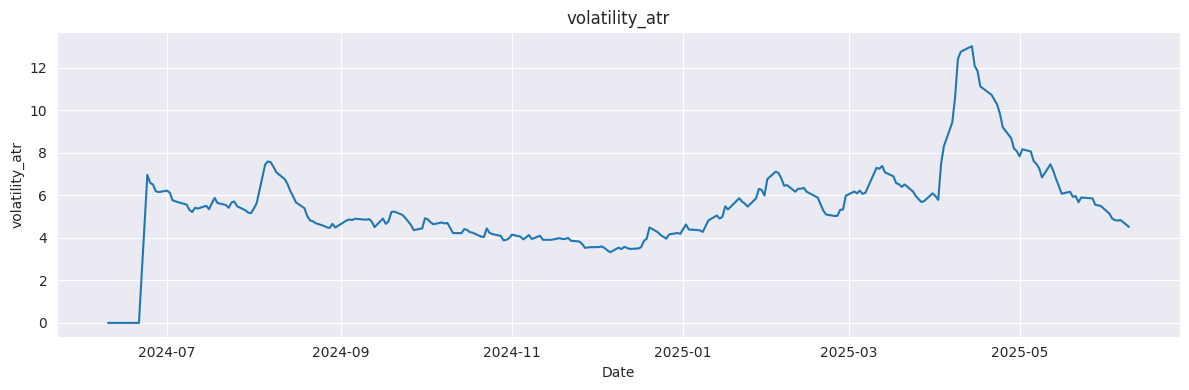

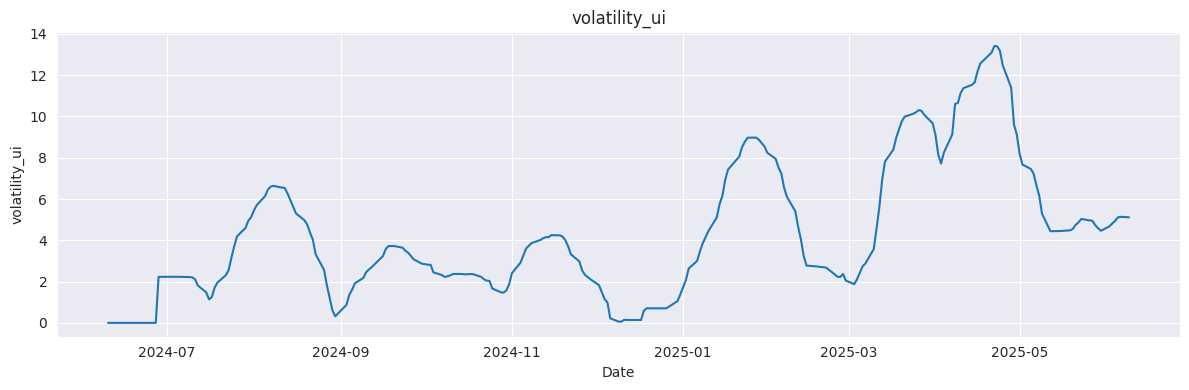

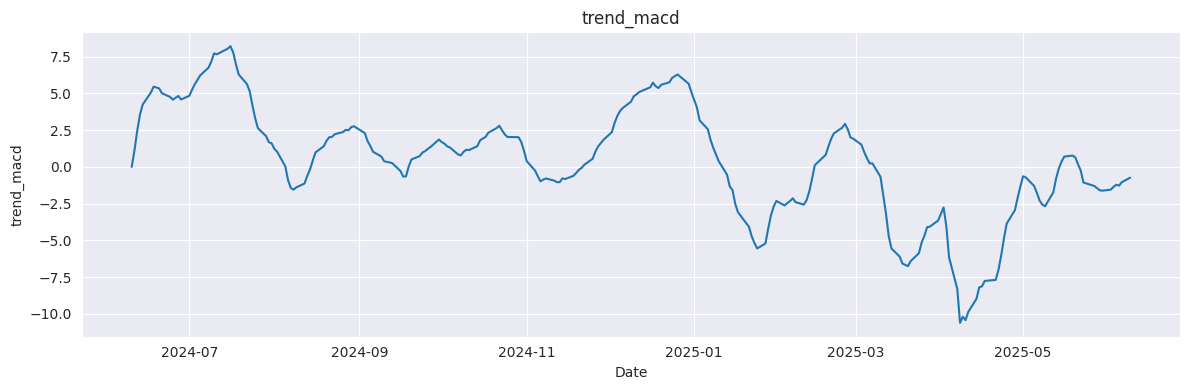

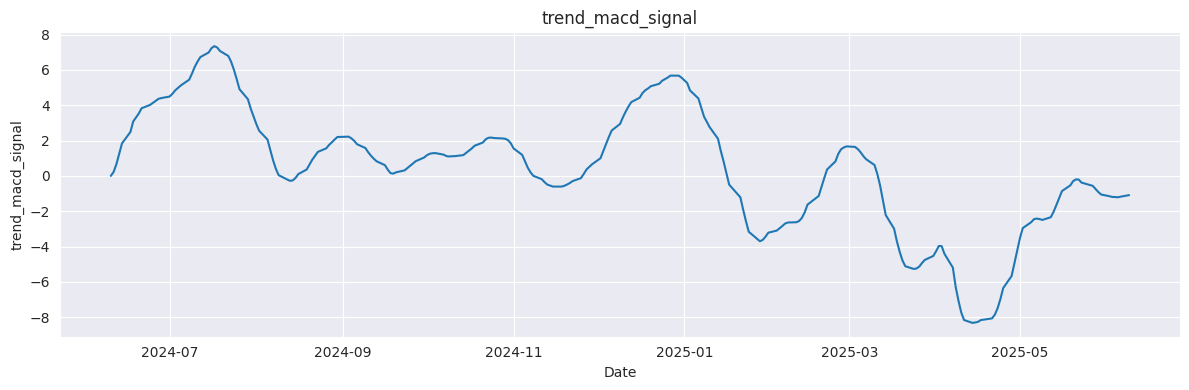

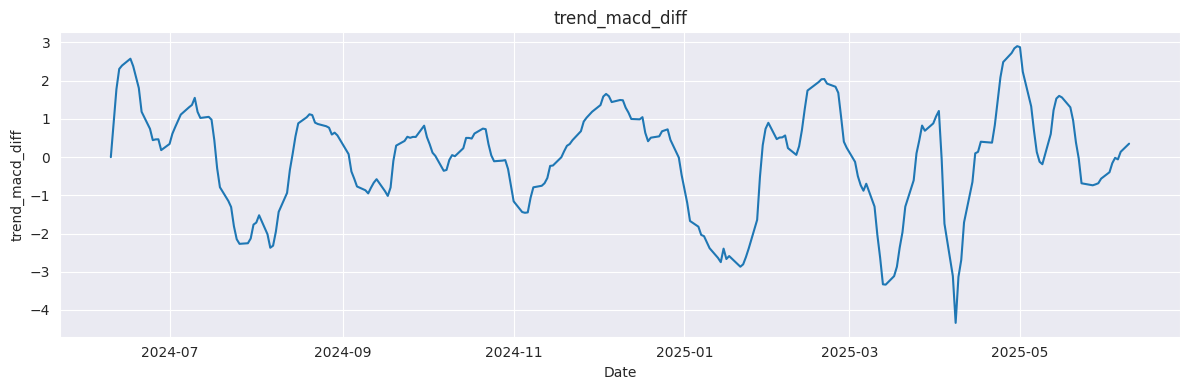

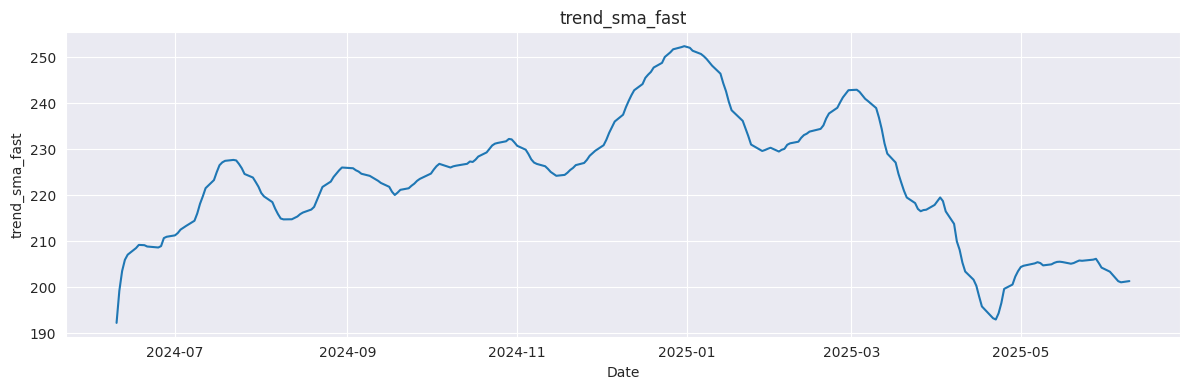

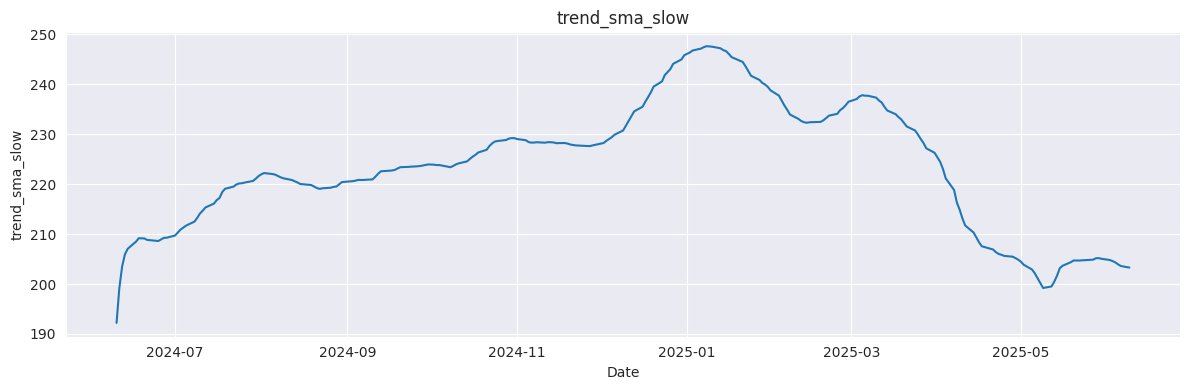

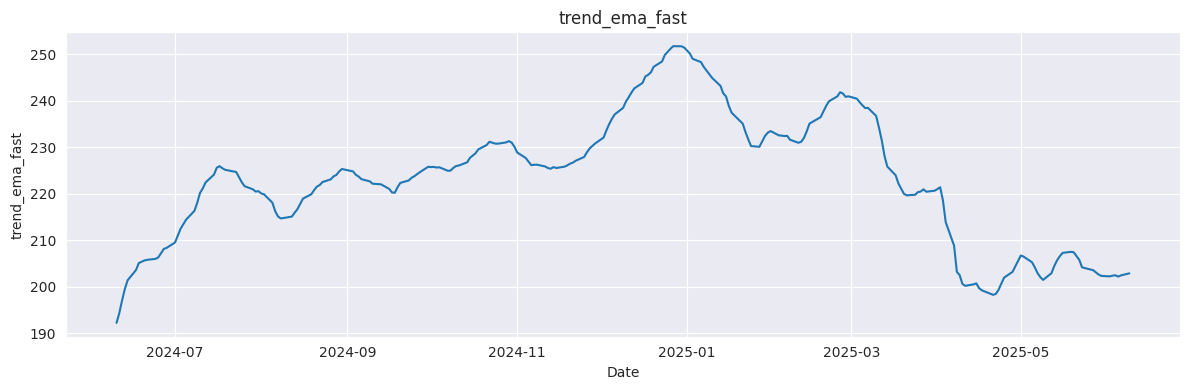

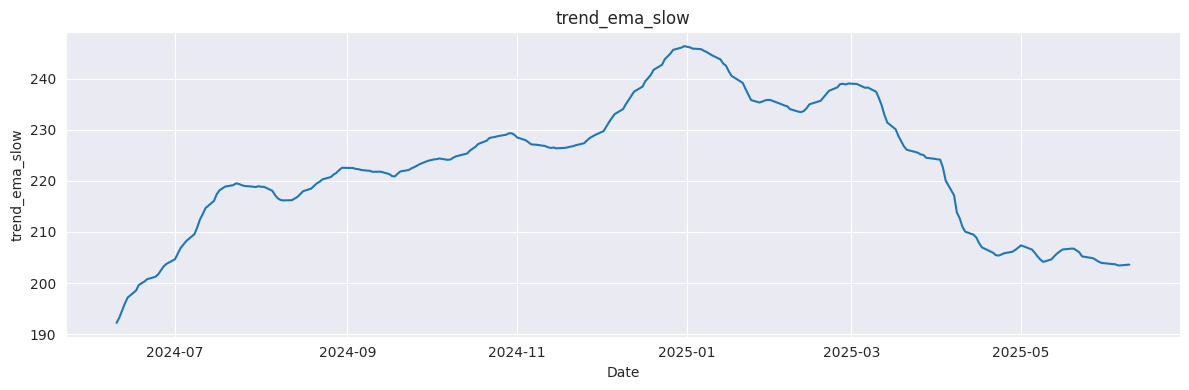

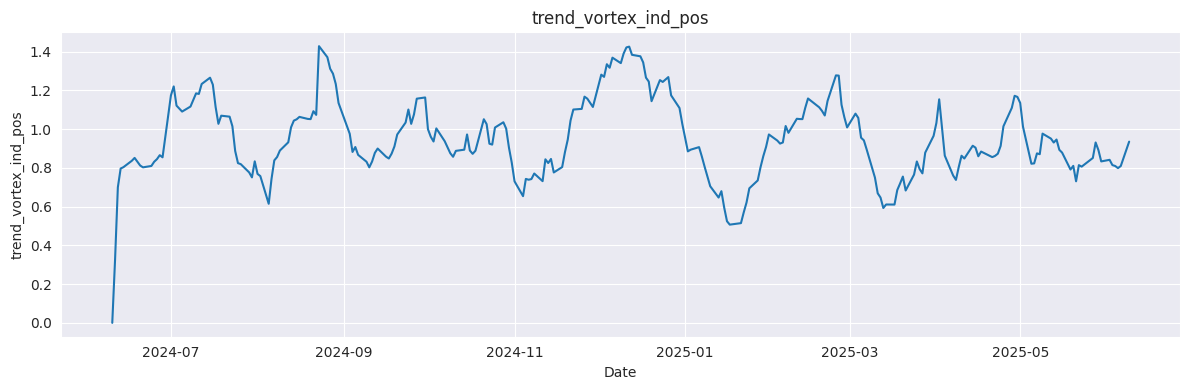

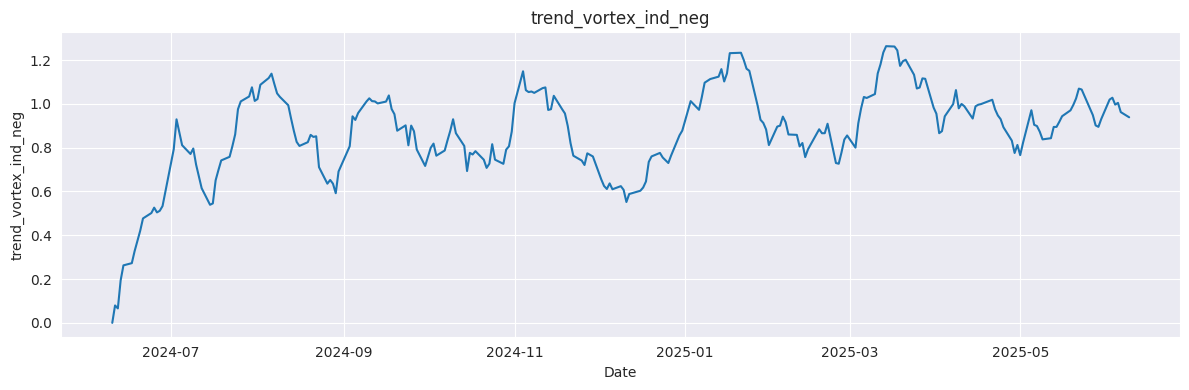

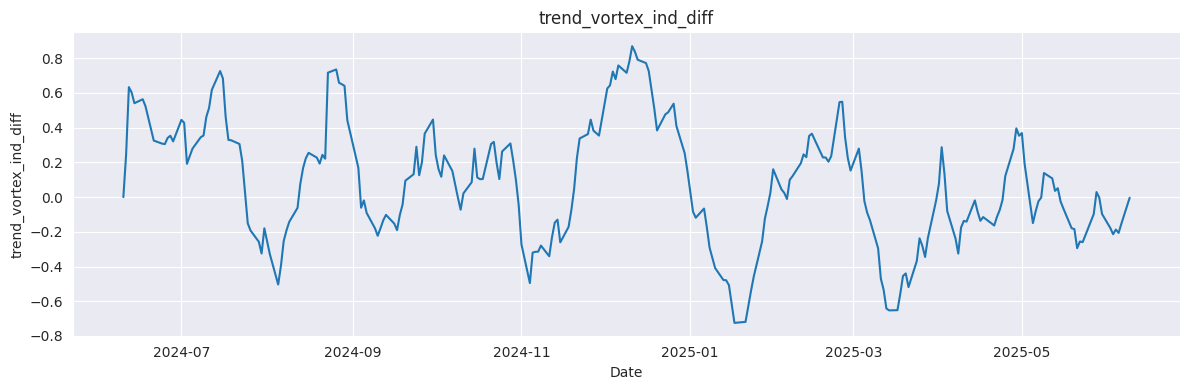

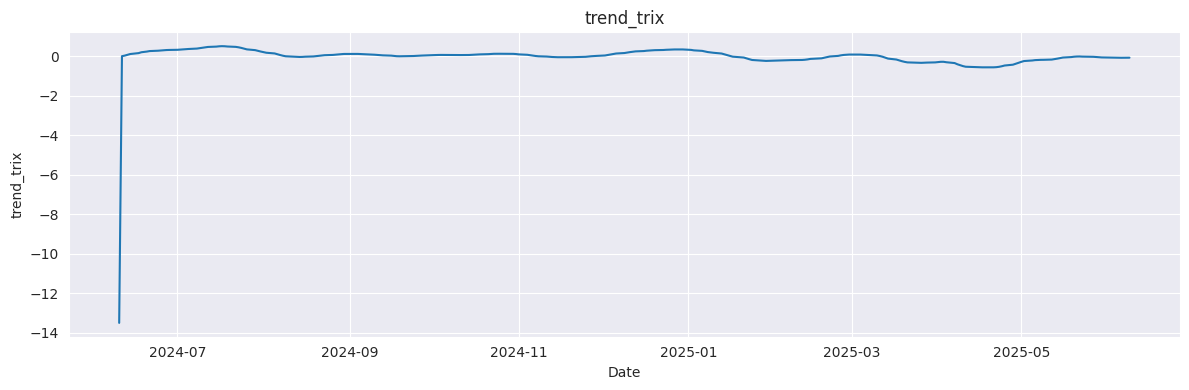

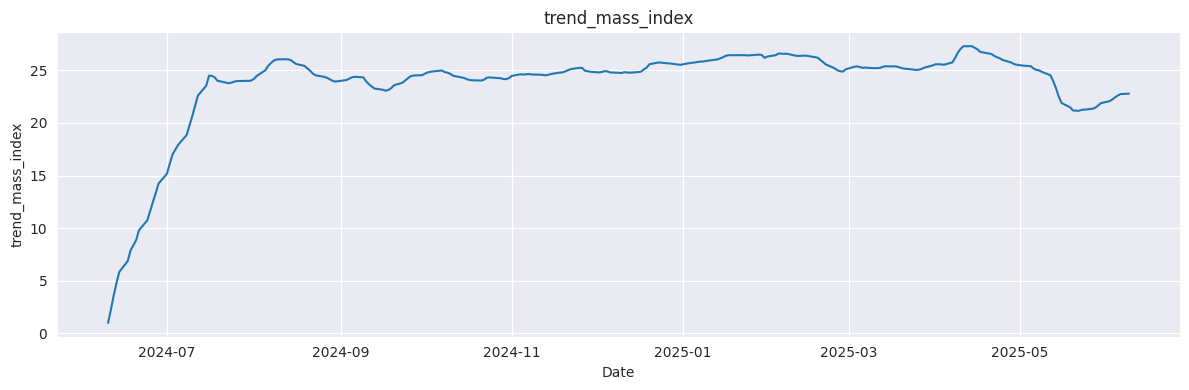

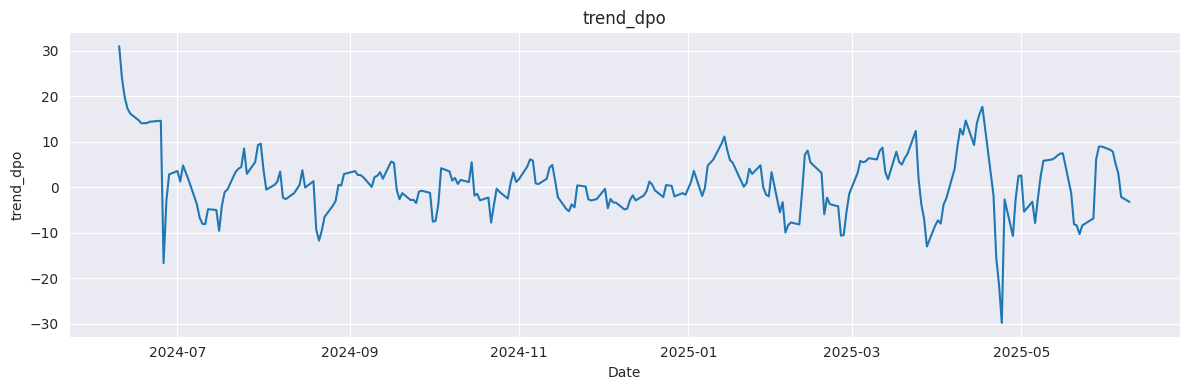

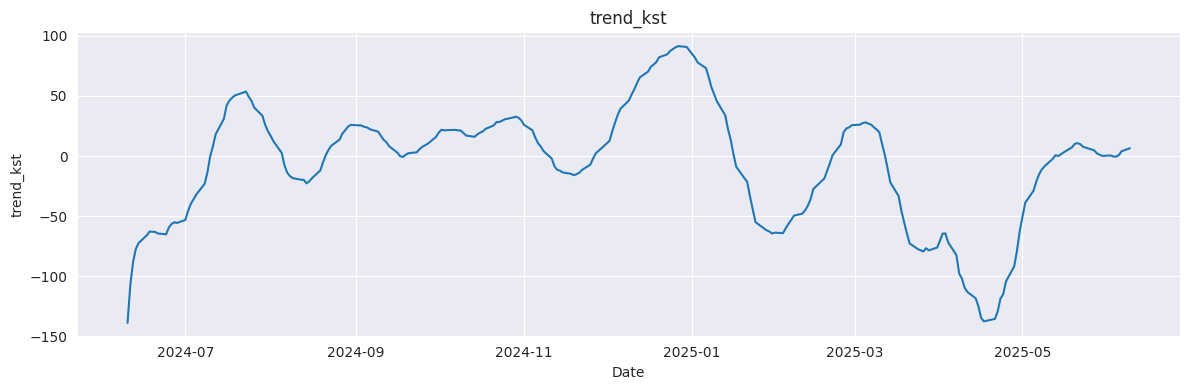

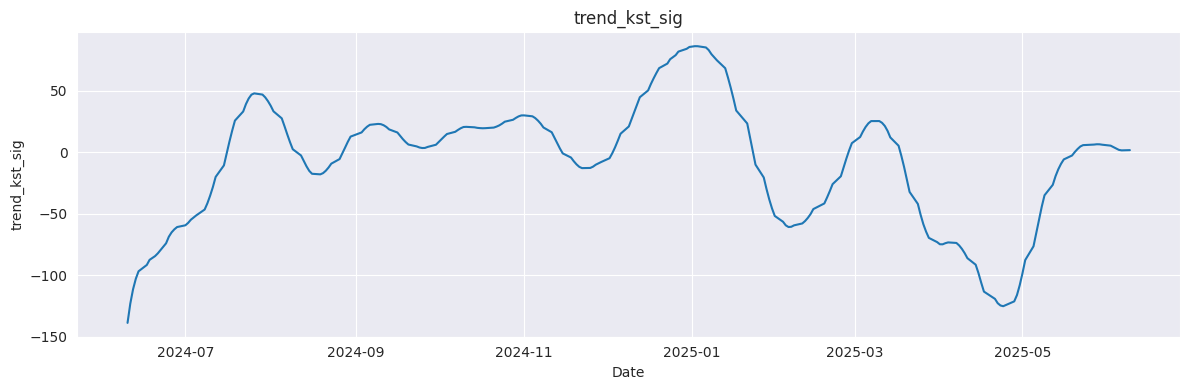

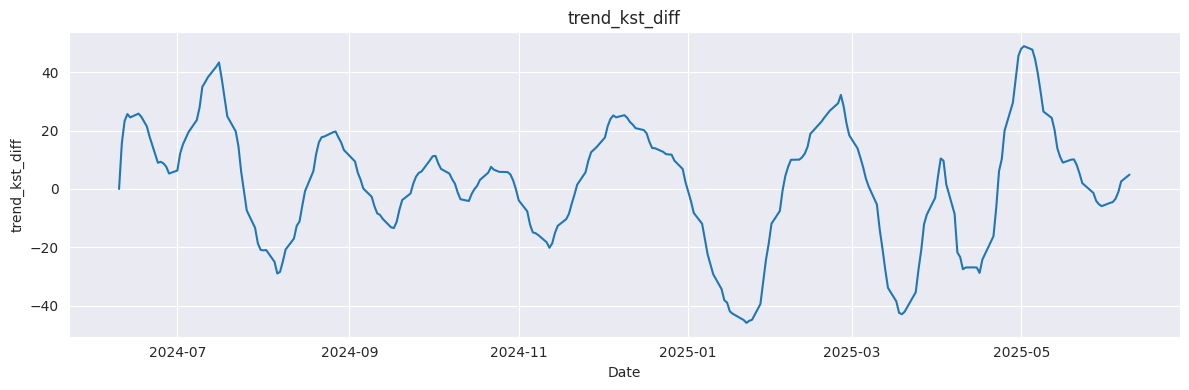

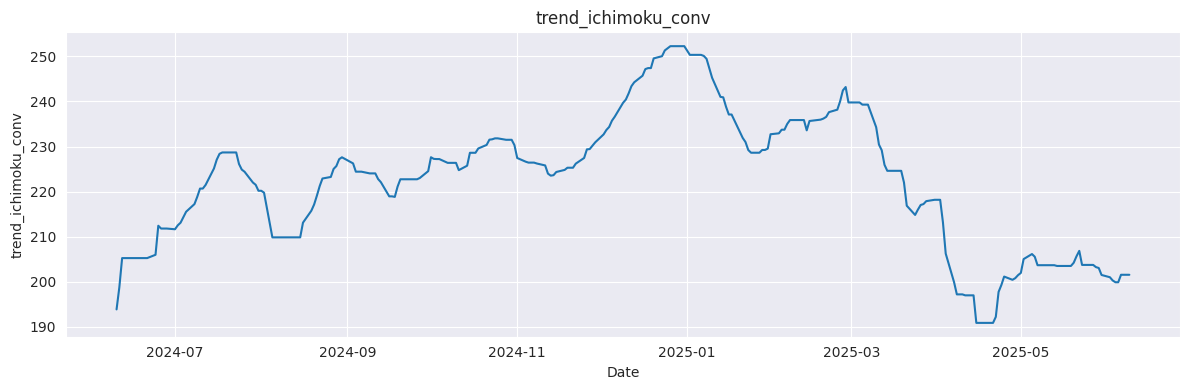

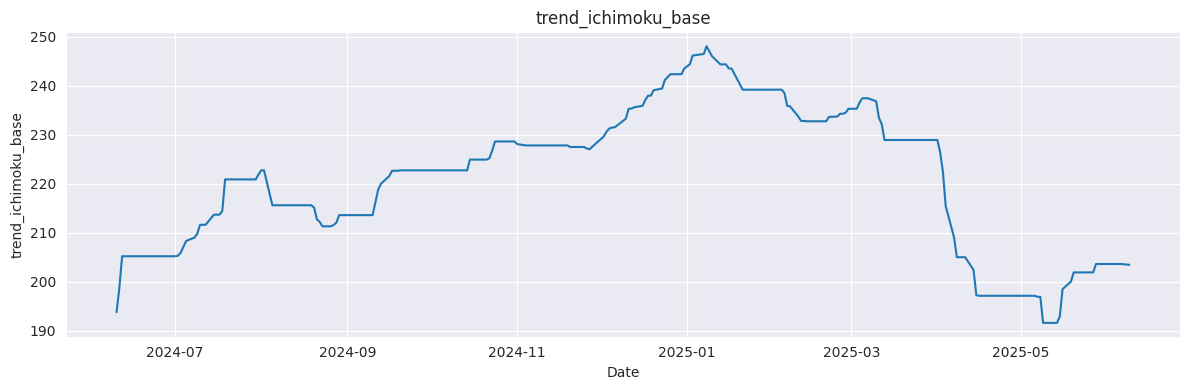

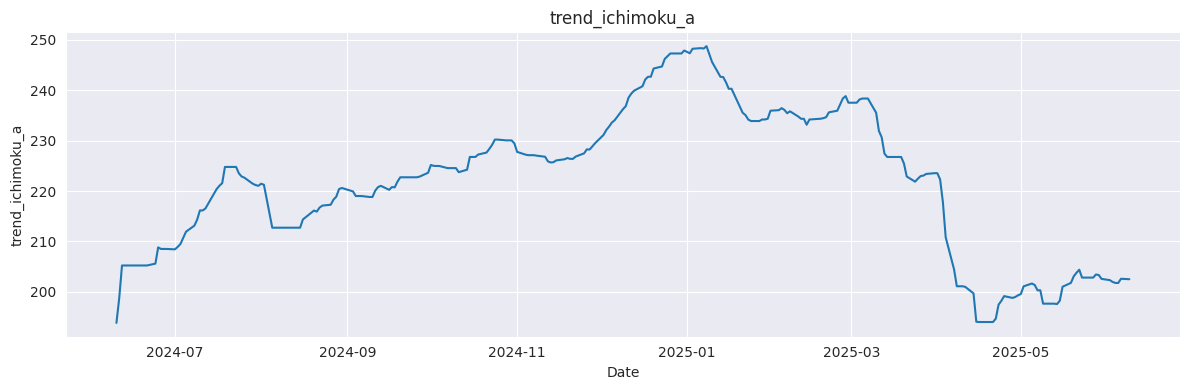

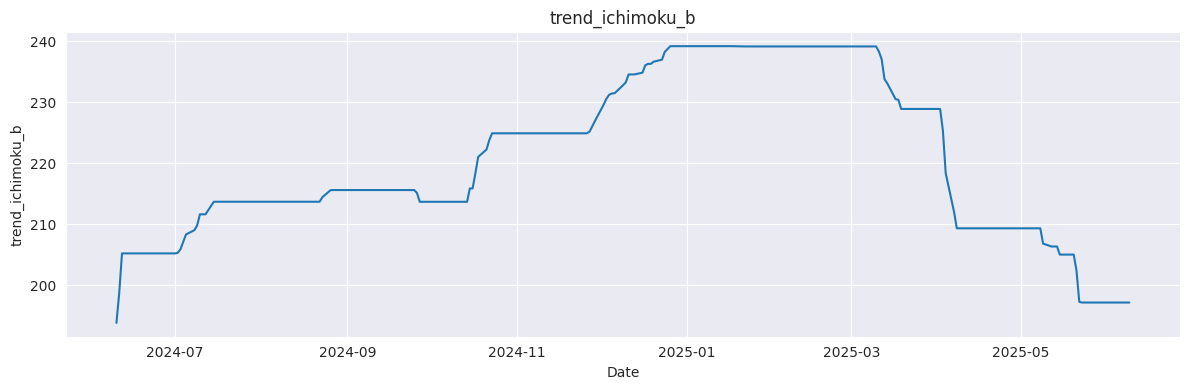

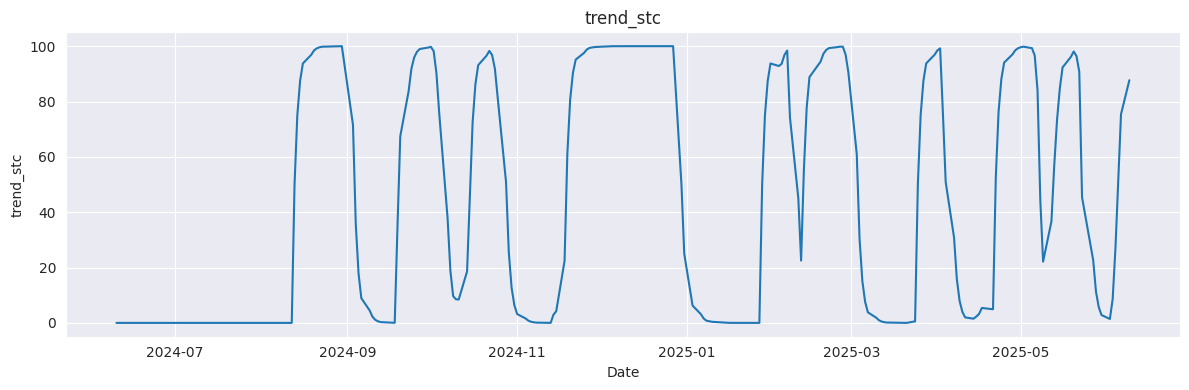

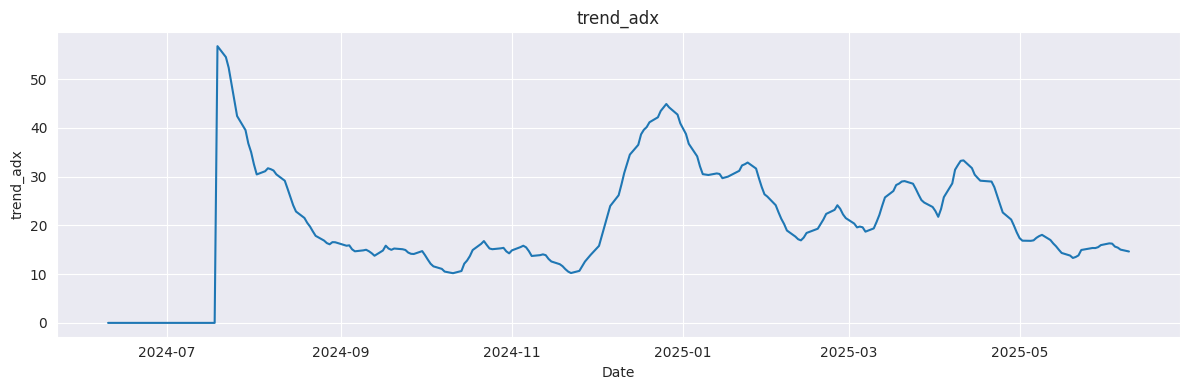

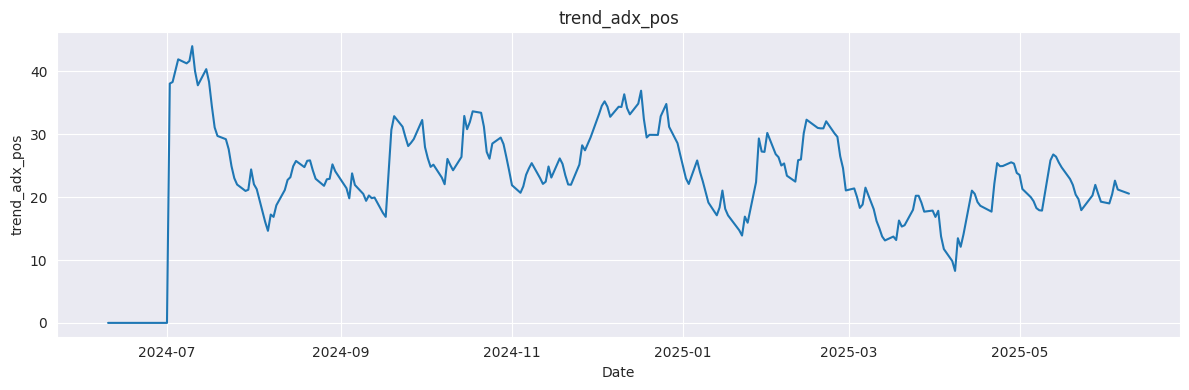

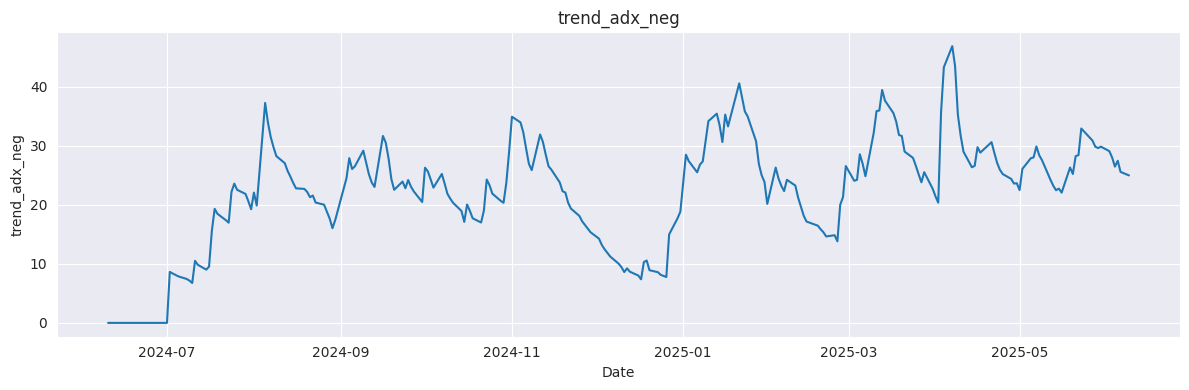

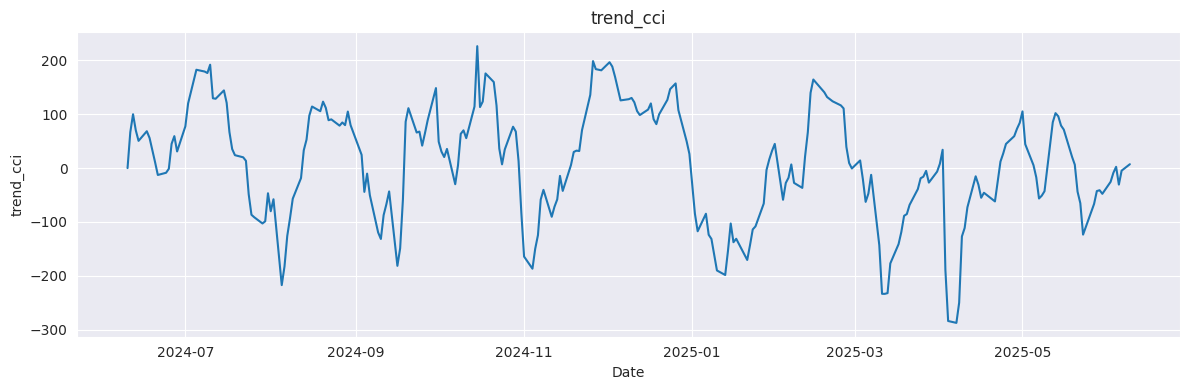

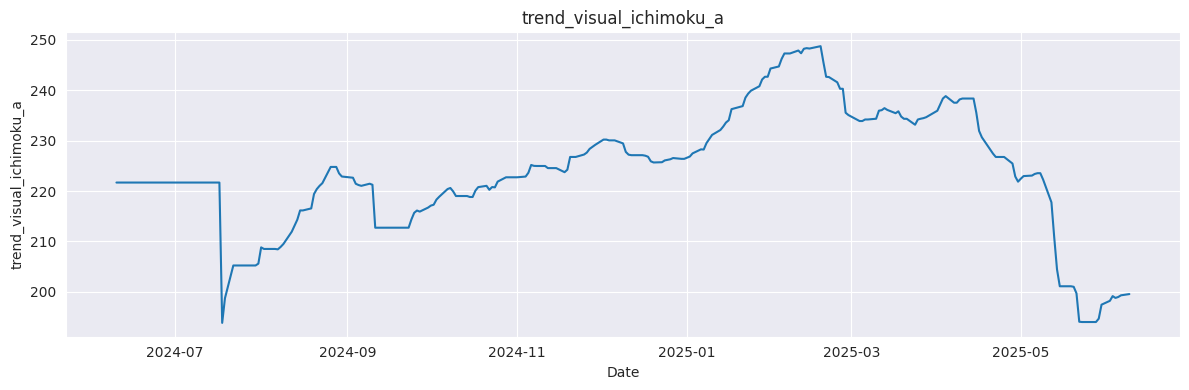

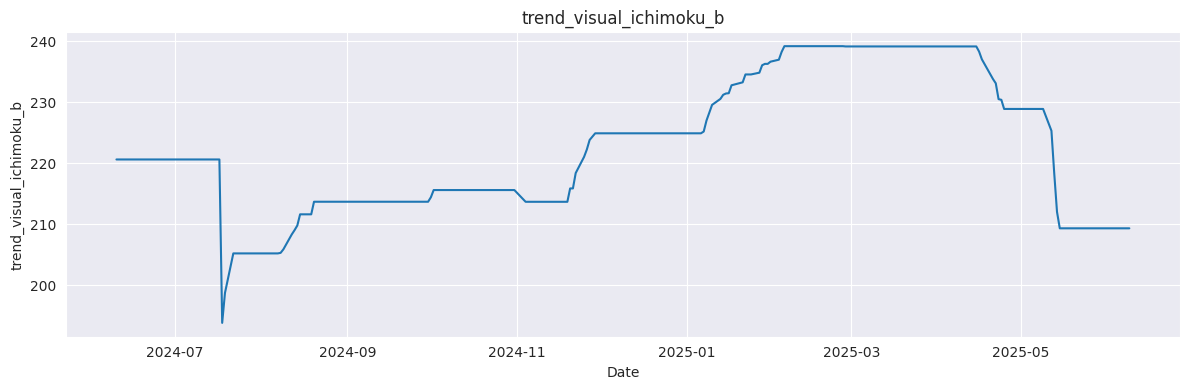

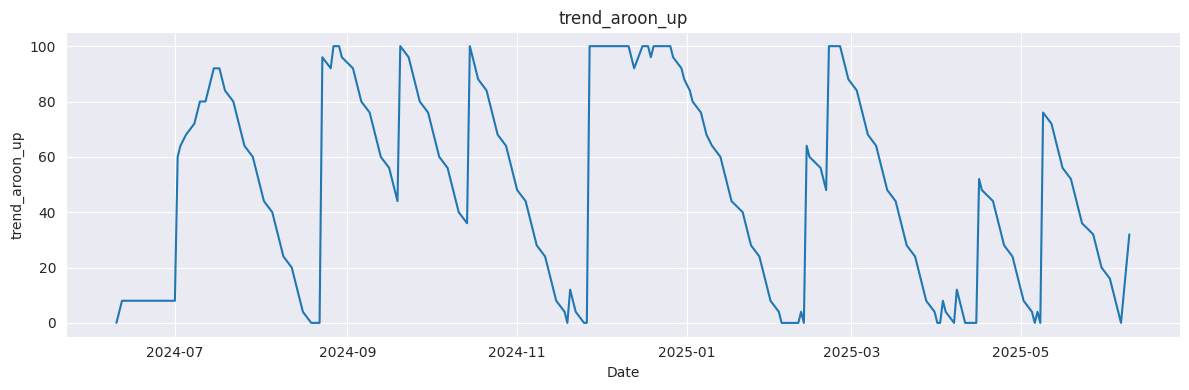

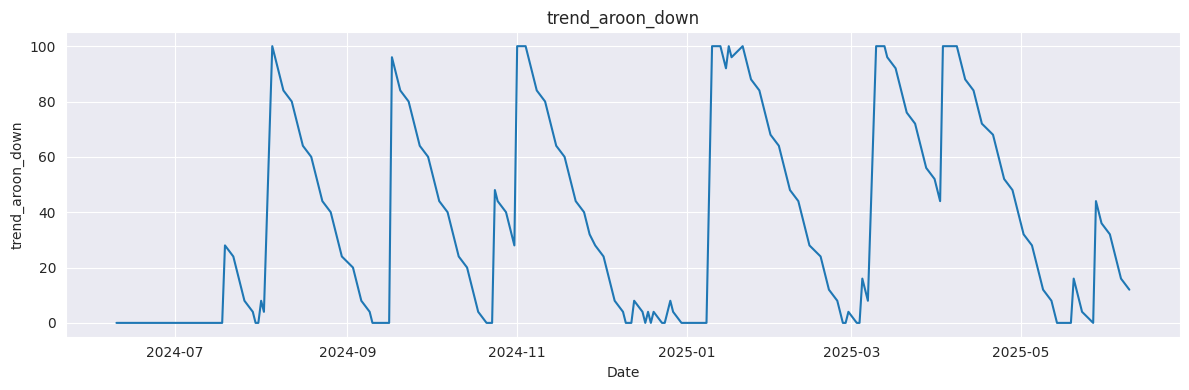

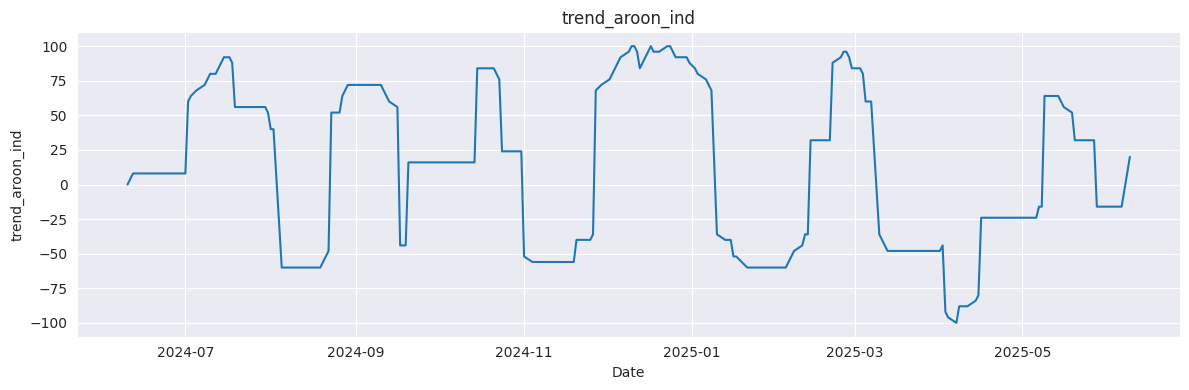

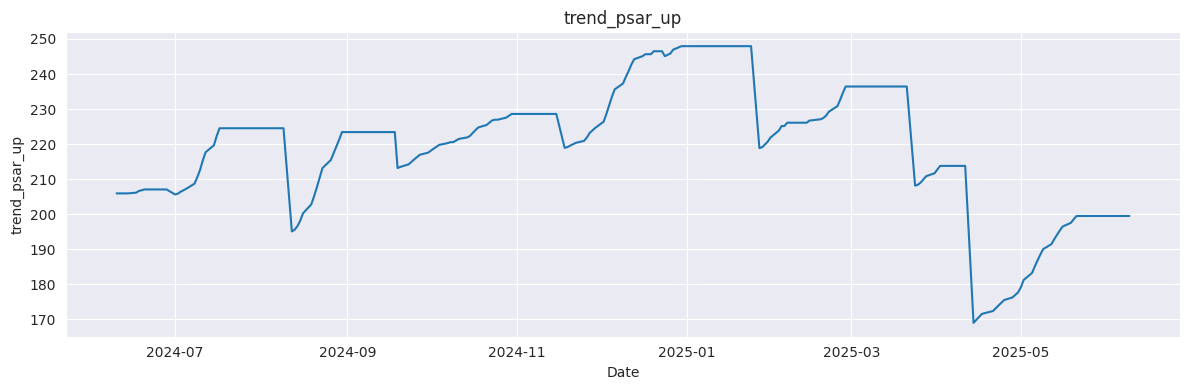

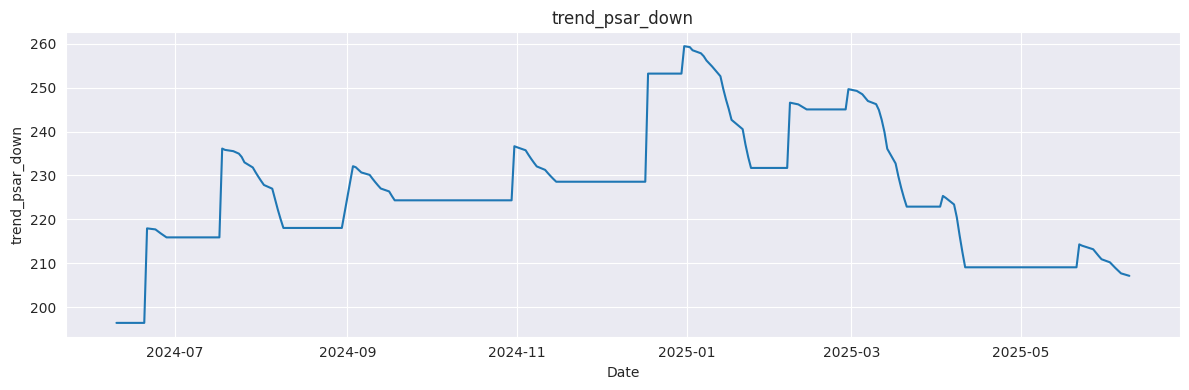

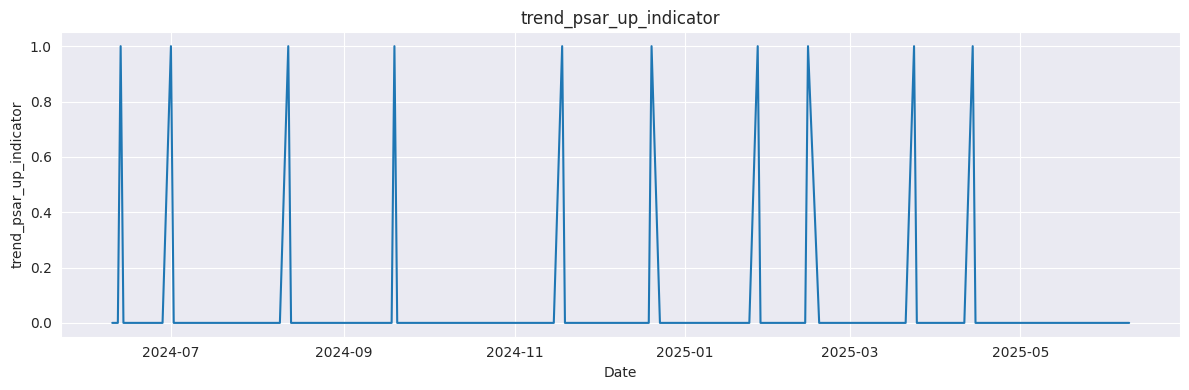

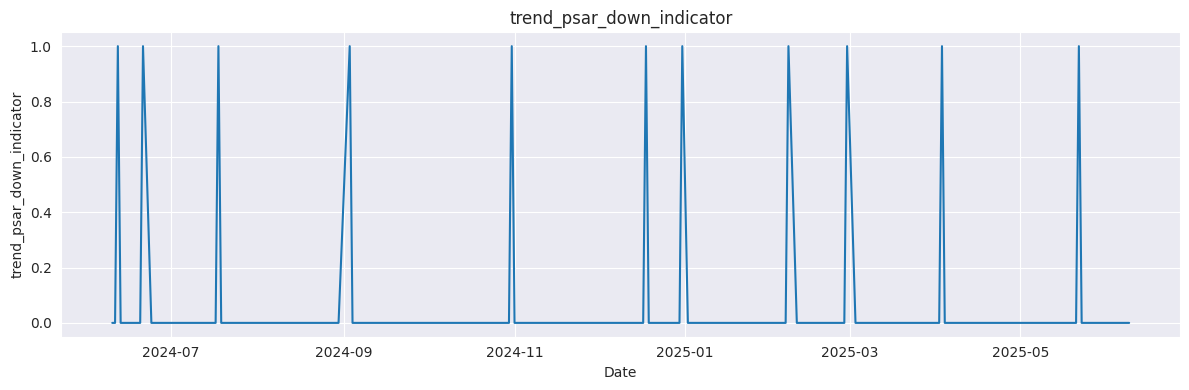

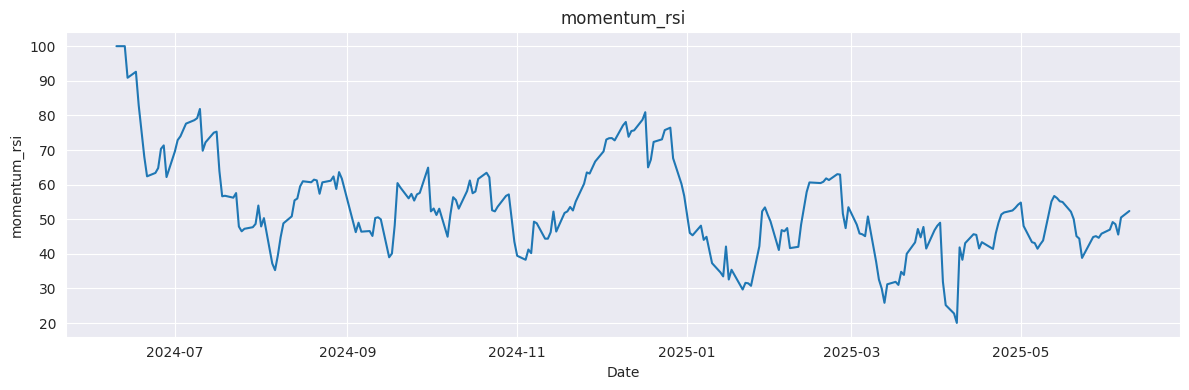

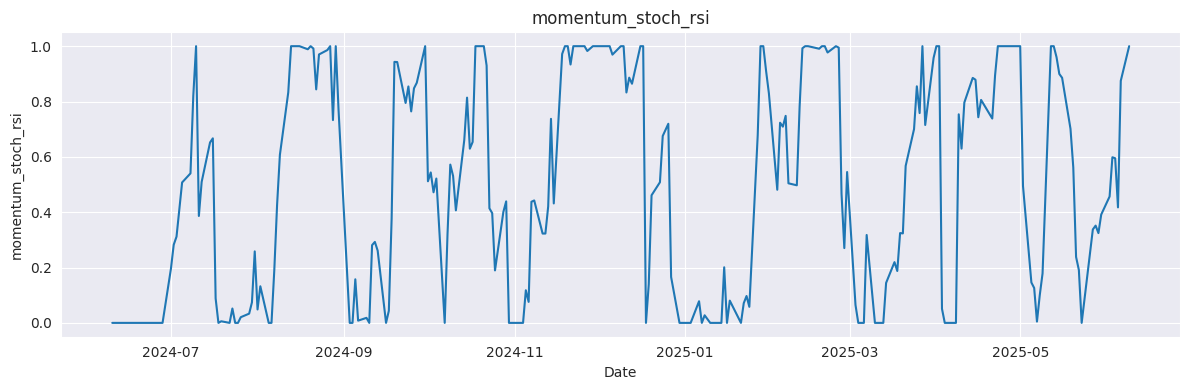

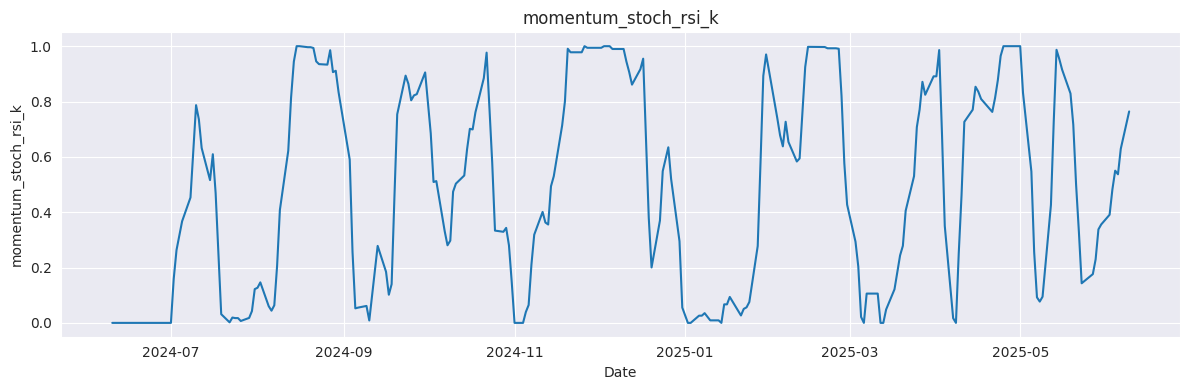

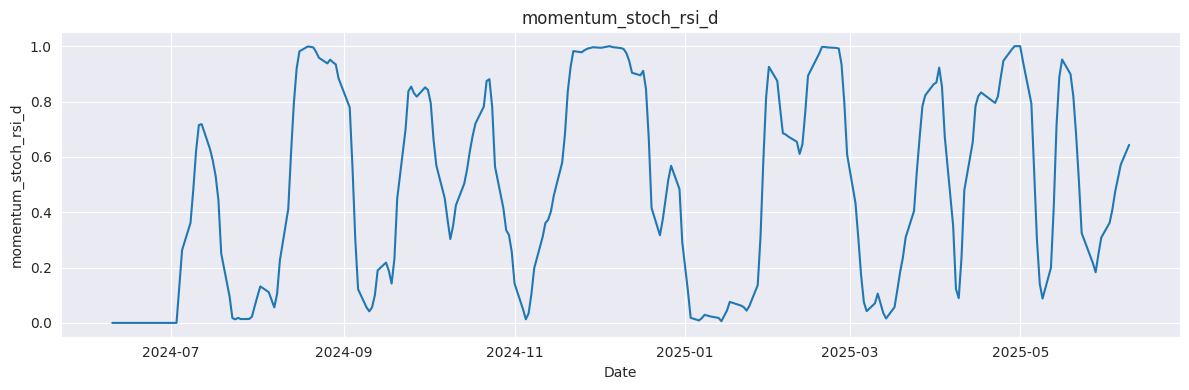

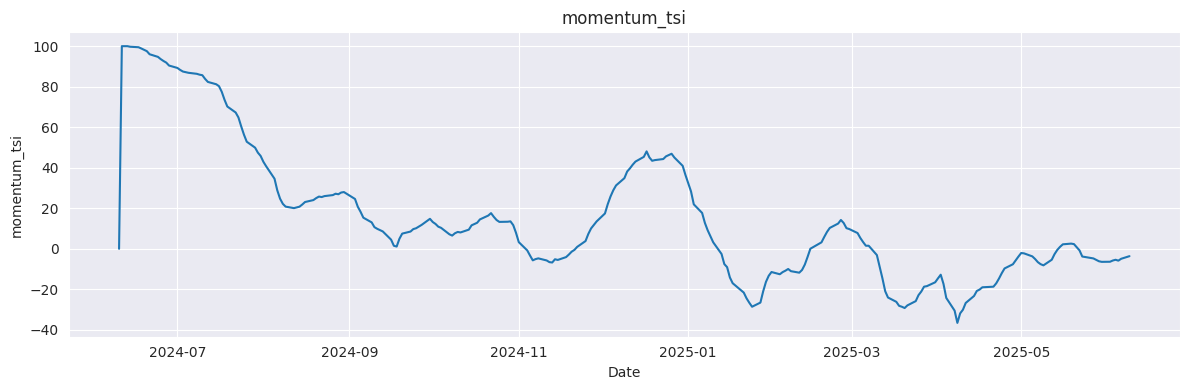

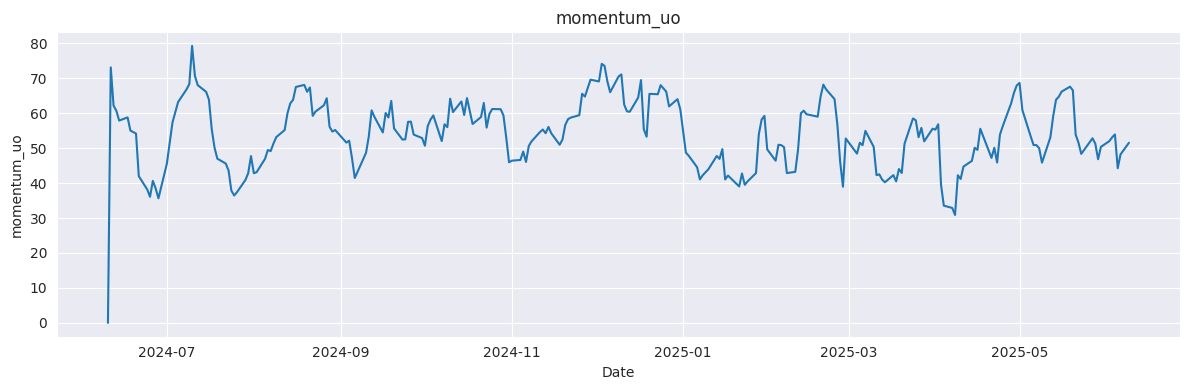

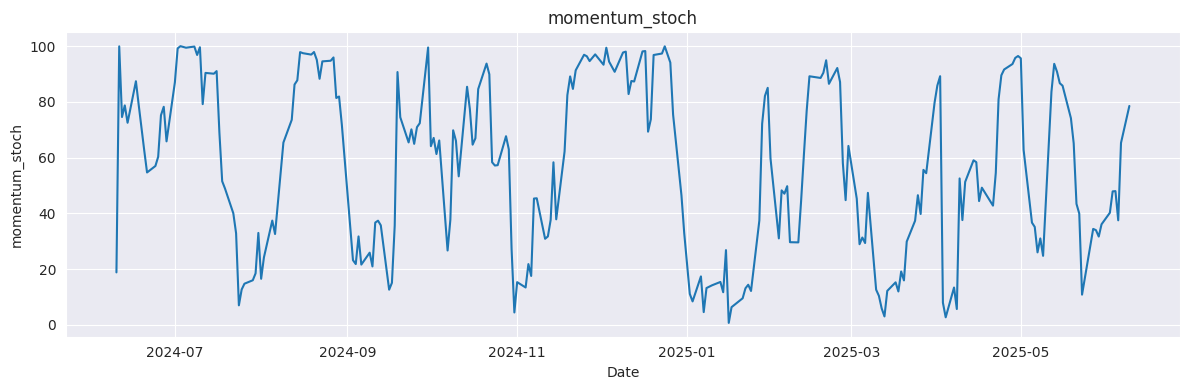

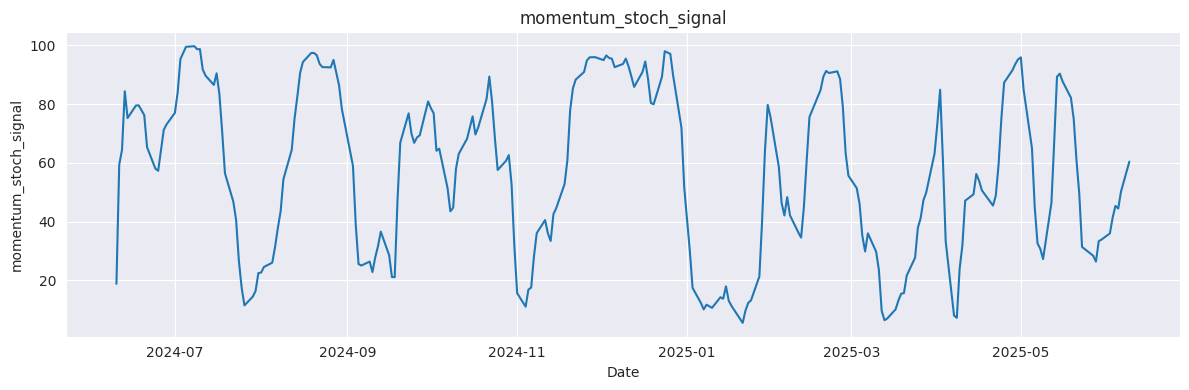

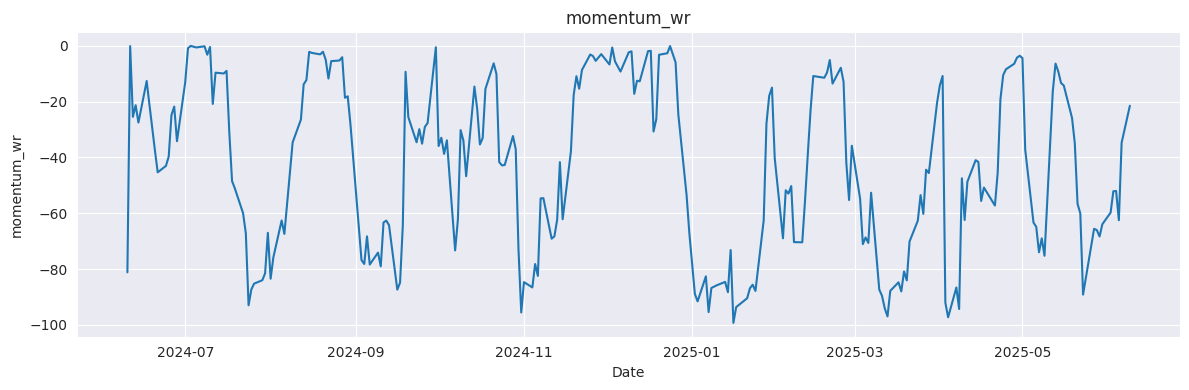

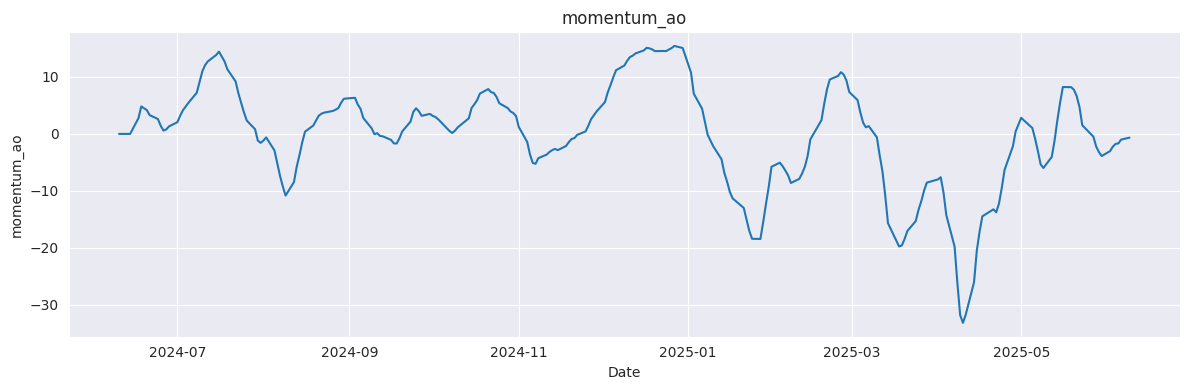

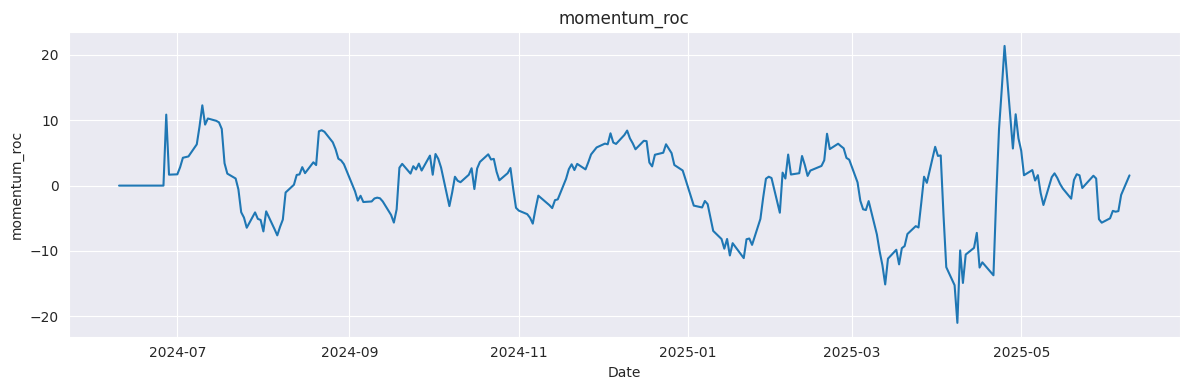

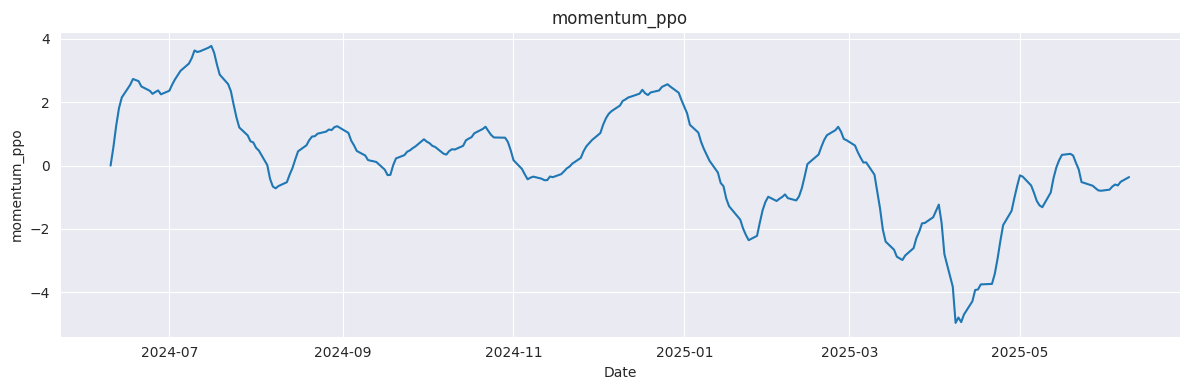

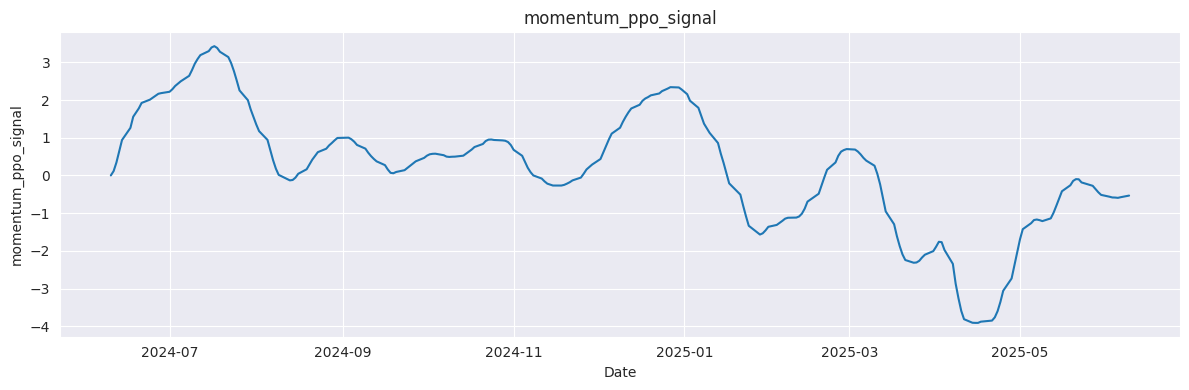

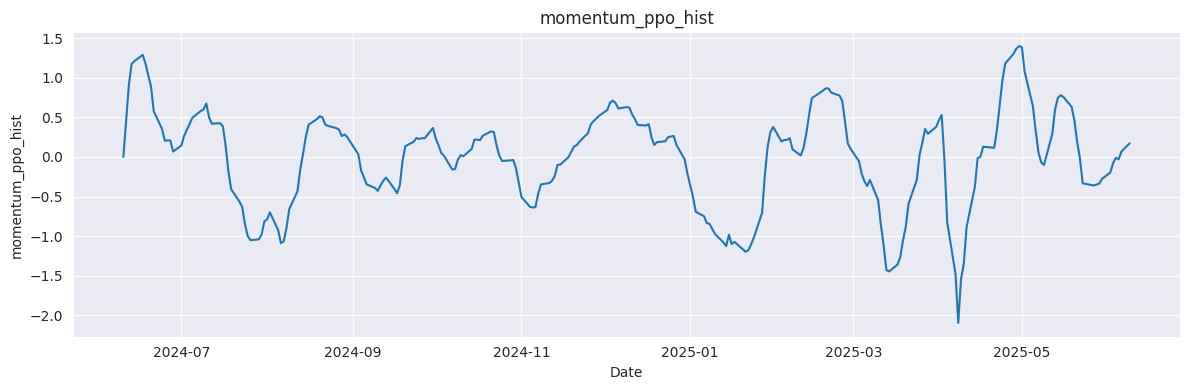

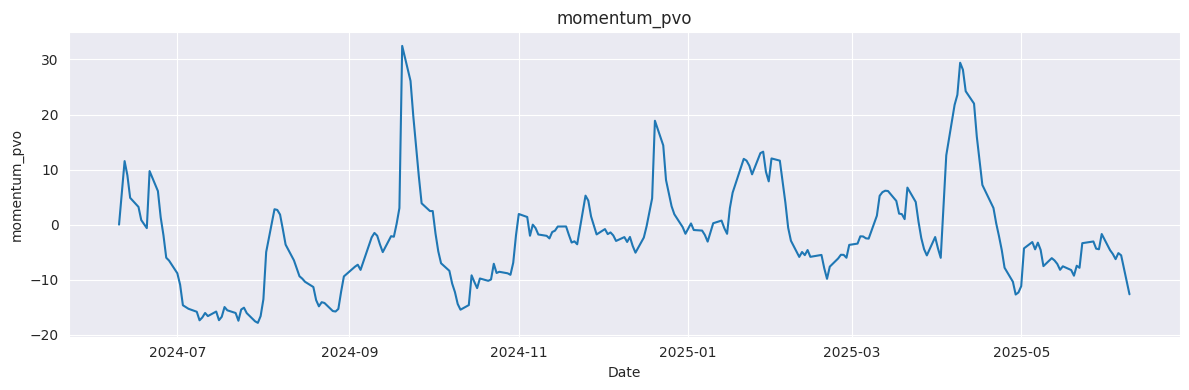

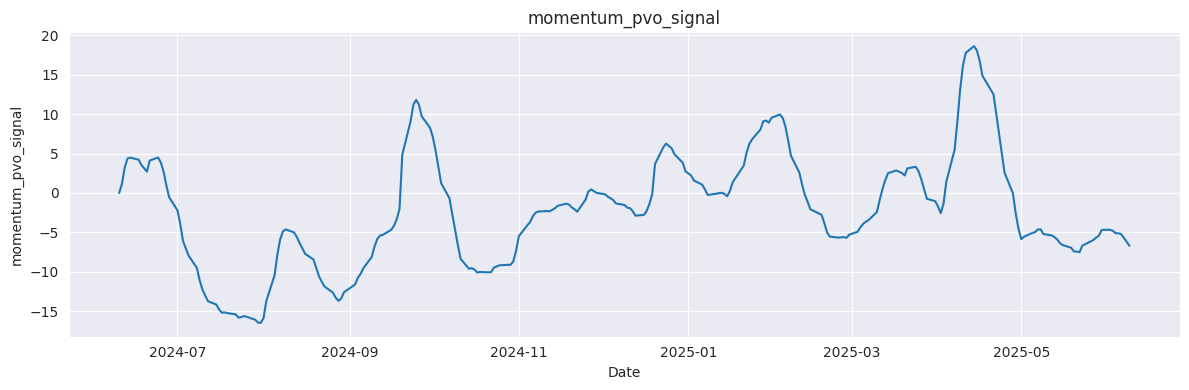

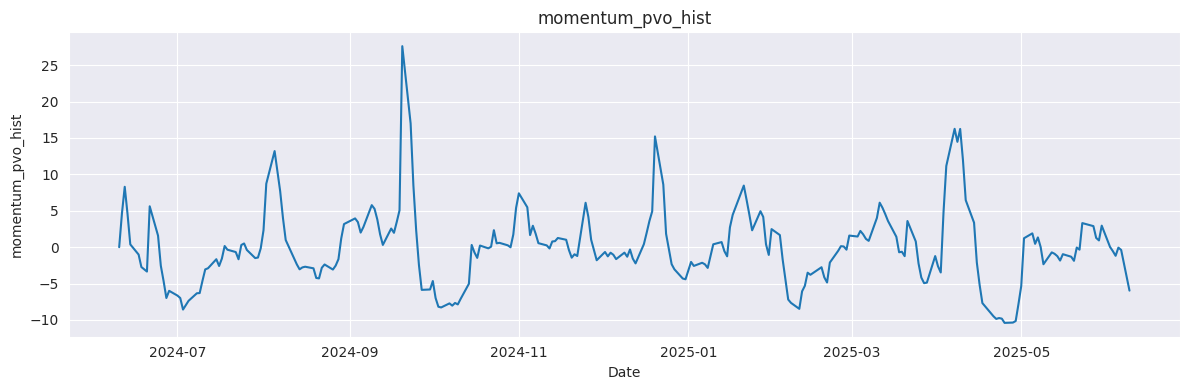

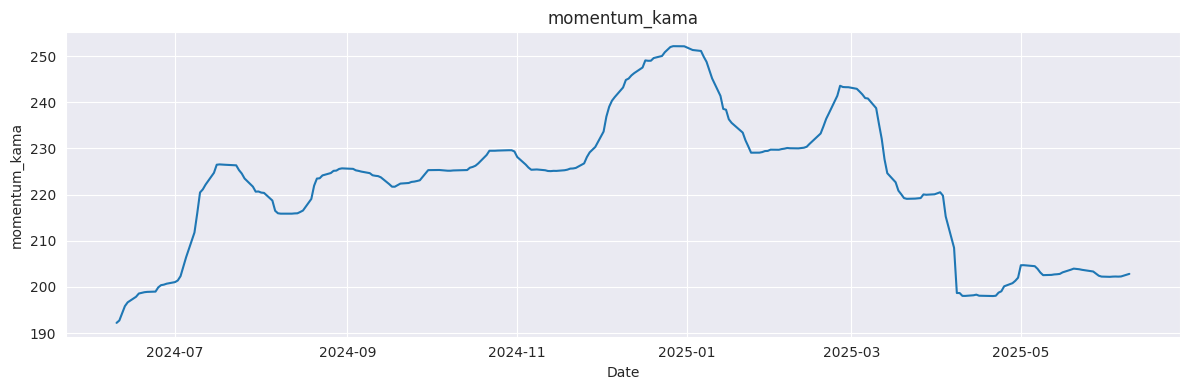

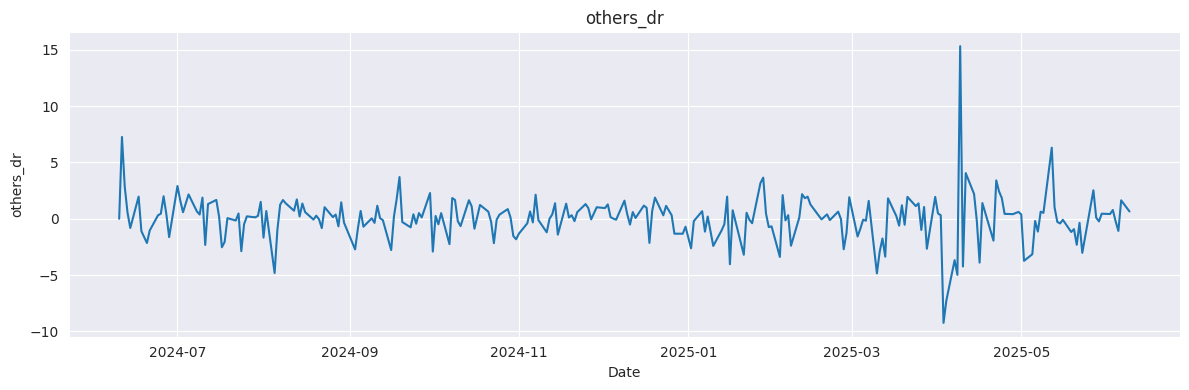

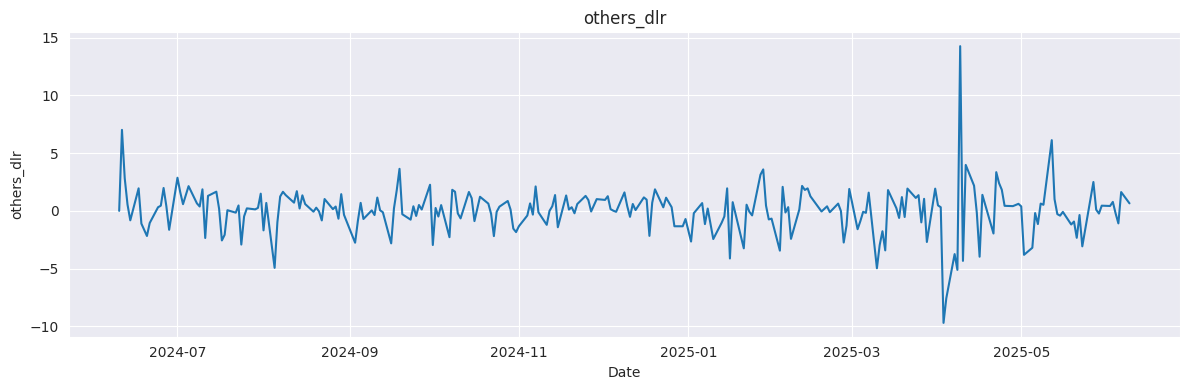

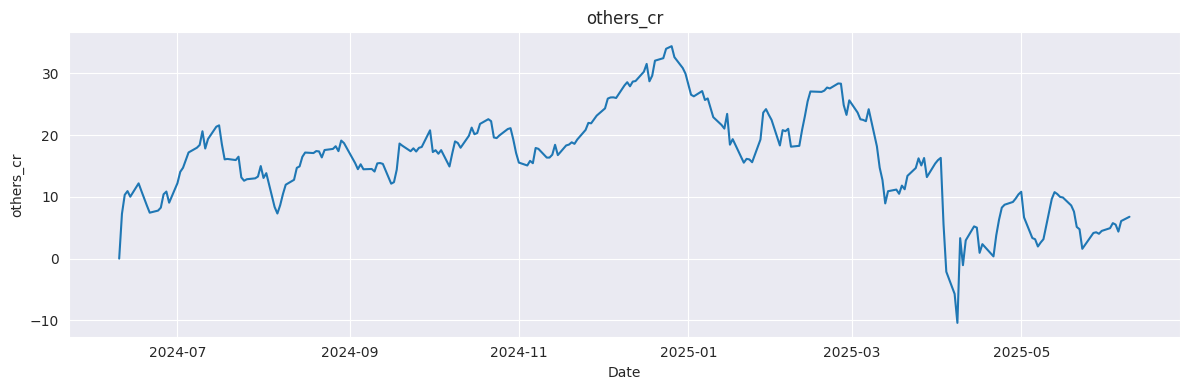

In [67]:
for ind in new_inds:
    plt.figure(figsize=(12,4))
    sns.lineplot(x=data_ta.index, y=data_ta[ind])
    plt.title(ind)
    plt.tight_layout()
    plt.show()

In [69]:
data_ta.to_csv('data_ta.csv', index=True, encoding='utf-8')